In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score

# Drivers of Cyberattack Severity: A Data Science Analysis of Financial Loss, User Impact, and Incident Response

### Author: **@AlexanderPanagyurski**, Date: March 2026, Data Science project

## 1. Abstract

This project presents a data science analysis of cyberattack severity, focusing on three key outcome dimensions: financial loss, user impact, and incident response. By integrating multiple cybersecurity datasets from independent sources, the study explores how attack type, target industry, geographic region, vulnerability category, and defense mechanisms relate to the overall severity of cyber incidents. The analysis combines data cleaning, consolidation, exploratory data analysis, statistical reasoning, and predictive modeling to identify patterns and factors associated with more damaging attacks. The goal is to better understand which characteristics of cyber incidents are most strongly linked to high impact and slower resolution, and to demonstrate how data-driven methods can support cybersecurity risk assessment.

## 2. Introduction


In the modern digital world, cybersecurity has become a major concern for governments, businesses, and individual users. As organizations increasingly rely on online services, cloud infrastructure, interconnected devices, and large-scale data systems, they become more exposed to cyber threats such as malware, phishing, ransomware, denial-of-service attacks, and unauthorized access. These incidents can disrupt operations, compromise sensitive information, damage reputation, and create significant economic losses.

The impact of cyberattacks is not uniform. Some incidents have limited consequences and are resolved quickly, while others affect millions of users, result in substantial financial damage, and require long and complex recovery efforts. Because of this, understanding cyberattack severity is an important problem in both research and practice. Identifying the characteristics that are associated with more severe incidents can support better risk assessment, prioritization of defenses, and faster incident response.

## 3. Problem Formulation

The main problem in this project is to understand which factors are associated with more severe cyberattacks. In practice, cyberattack severity is not a single concept, so it is analyzed through three measurable dimensions: financial loss, number of affected users, and incident response time. The project studies how these outcomes vary depending on attack type, industry, vulnerability, defense mechanism, and operational indicators.

## 4. Research Questions and Objectives


Based on the problem formulation, this project investigates cyberattack severity through a set of focused research questions. The analysis is centered on three outcome dimensions: financial loss, user impact, and incident response time. These dimensions are used as practical indicators of how severe a cyber incident is.

#### 4.1. Main Research Question

Which characteristics of cyberattacks are most strongly associated with higher financial loss, greater user impact, and longer incident response times?

#### 4.2. Sub-questions

1. Which attack types are associated with the highest average financial loss?
2. Which industries or sectors experience the greatest user impact from cyber incidents?
3. Which factors are associated with longer incident resolution times?
4. How do vulnerability categories, defense mechanisms, and operational indicators relate to severity?
5. To what extent can severity-related outcomes be estimated or predicted from available cyberattack features?

## 5. Data Exploration

This project uses two independent datasets related to cybersecurity incidents and attacks **[cybersecurity_attacks.csv](https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks/data)**, **[Global_Cybersecurity_Threats_2015-2024.csv](https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024)**. 

### 5.1. Dataset 1: [Global Cybersecurity Threats (2015-2024)](https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024)

This dataset provides a global, incident-oriented view of cybersecurity threats and is the primary source used to study cyberattack severity in terms of financial loss, user impact, and incident response time. It contains observations from multiple countries, years, attack types, industries, and security contexts. Because it includes both explanatory variables and severity-related outcomes, it serves as the core dataset for the main analytical part of the project.

#### 5.1.1. Load and preview the dataset

In [2]:
# load dataframe 
global_cybersecuirty_threats = pd.read_csv('data/Global_Cybersecurity_Threats_2015-2024.csv')
global_cybersecuirty_threats

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68
...,...,...,...,...,...,...,...,...,...,...
2995,UK,2021,Ransomware,Government,51.42,190694,Unknown,Social Engineering,Firewall,52
2996,Brazil,2023,SQL Injection,Telecommunications,30.28,892843,Hacker Group,Zero-day,VPN,26
2997,Brazil,2017,SQL Injection,IT,32.97,734737,Nation-state,Weak Passwords,AI-based Detection,30
2998,UK,2022,SQL Injection,IT,32.17,379954,Insider,Unpatched Software,Firewall,9


#### 5.1.2. Check shape and column names

In [3]:
# Check shape and column names
print("Shape:", global_cybersecuirty_threats.shape)
print("\nColumns:")
print(global_cybersecuirty_threats.columns.tolist())

Shape: (3000, 10)

Columns:
['Country', 'Year', 'Attack Type', 'Target Industry', 'Financial Loss (in Million $)', 'Number of Affected Users', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used', 'Incident Resolution Time (in Hours)']


To improve code readability and follow Python naming conventions, will rename dataframe columns to lowercase snake_case format. This makes later analysis, visualization, and modeling steps easier to write and maintain.

In [4]:
# rename the columns to follow python convention (snake_case) 
global_cybersecuirty_threats = global_cybersecuirty_threats.rename(columns={
    "Country": "country",
    "Year": "year",
    "Attack Type": "attack_type",
    "Target Industry": "target_industry",
    "Financial Loss (in Million $)": "financial_loss_in_millions_usd",
    "Number of Affected Users": "number_of_affected_users",
    "Attack Source": "attack_source",
    "Security Vulnerability Type": "security_vulnerability_type",
    "Defense Mechanism Used": "defense_mechanism_used",
    "Incident Resolution Time (in Hours)": "incident_resolution_time_in_hours"
})

In [5]:
print("\nColumns:")
print(global_cybersecuirty_threats.columns.tolist())


Columns:
['country', 'year', 'attack_type', 'target_industry', 'financial_loss_in_millions_usd', 'number_of_affected_users', 'attack_source', 'security_vulnerability_type', 'defense_mechanism_used', 'incident_resolution_time_in_hours']


#### 5.1.3. Inspect data types and missing values

In [6]:
# checks if at least one missing value exists per column
global_cybersecuirty_threats.isna().any()

country                              False
year                                 False
attack_type                          False
target_industry                      False
financial_loss_in_millions_usd       False
number_of_affected_users             False
attack_source                        False
security_vulnerability_type          False
defense_mechanism_used               False
incident_resolution_time_in_hours    False
dtype: bool

#### 5.1.4. Summary statistics

In [7]:
global_cybersecuirty_threats.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,3000,10,UK,321,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,3000.0,NaN,NaN,NaN,2019.570333,2.857932,2015.0,2017.0,2020.0,2022.0,2024.0
attack_type,3000,6,DDoS,531,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target_industry,3000,7,IT,478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
financial_loss_in_millions_usd,3000.0,NaN,NaN,NaN,50.49297,28.791415,0.5,25.7575,50.795,75.63,99.99
number_of_affected_users,3000.0,NaN,NaN,NaN,504684.136333,289944.084972,424.0,255805.25,504513.0,758088.5,999635.0
attack_source,3000,4,Nation-state,794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
security_vulnerability_type,3000,4,Zero-day,785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
defense_mechanism_used,3000,5,Antivirus,628,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incident_resolution_time_in_hours,3000.0,NaN,NaN,NaN,36.476,20.570768,1.0,19.0,37.0,55.0,72.0


1. `country`
   - 3000 values
   - 10 unique countries
   - most frequent country: UK
   - frequency of UK: 321

**Observation:**

This is a **categorical geographic variable** describing where the incident occurred.
There are only 10 countries in the dataset, so the international coverage is broad but still limited. The UK appears most often, but not overwhelmingly, which suggests the country distribution is relatively balanced rather than dominated by a single location.

2. `year`
    - mean: 2019.57
    - standard deviation: 2.86
    - min: 2015
    - 25%: 2017
    - median: 2020
    - 75%: 2022
    - max: 2024

**Observation:**

This column covers the period from 2015 to 2024, which gives a 10-year time span. The median year is 2020, meaning the observations are centered around the middle of that period. The spread is moderate, and the values appear well distributed across time.

3. `attack_type`
   - 3000 values
   - 6 unique attack types
   - most frequent type: DDoS
   - frequency: 531

**Observation:**

This is one of the most important explanatory variables in the dataset. With only 6 categories, it is easy to compare attack types directly. DDoS is the most common category, but again not to an extreme degree, so the variable looks reasonably balanced.

4. `target_industry`
    - 3000 values
    - 7 unique industries
    - most frequent industry: IT
    - frequency: 478

**Observation:**

This variable describes which industry was targeted by the attack. There are 7 sectors, which is enough for meaningful comparison without making the analysis too fragmented. IT is the most frequent, which is plausible given the project topic.

5. `financial_loss_in_millions_usd`
   - mean: 50.49
   - standard deviation: 28.79
   - min: 0.5
   - 25%: 25.76
   - median: 50.80
   - 75%: 75.63
   - max: 99.99

**Observation:**

This is one of the main severity outcome variables. The average loss is around 50.5 million USD, and the median is very close to the mean, which suggests the distribution is fairly symmetric rather than heavily skewed. The range is wide, from 0.5 million to almost 100 million USD, meaning the dataset includes both low-impact and high-impact incidents.

The standard deviation is also large, showing substantial variation in financial damage across incidents.

6. `number_of_affected_users`
    - mean: 504 684
    - standard deviation: 289 944
    - min: 424
    - 25%: 255 805
    - median: 504 513
    - 75%: 758 089
    - max: 999 635

**Observation:**

This is the second major severity outcome variable. The average and median are almost identical, which again suggests a fairly symmetric distribution. The range is very large: some incidents affect only a few hundred users, while others affect nearly one million.

The large standard deviation indicates strong variation in user impact.
    
7. `attack_source`
    - 3000 values
    - 4 unique categories
    - most frequent source: Nation-state
    - frequency: 794

**Observation:**

This variable identifies the origin or actor category behind the attack. Only 4 source categories are present, which makes it simple to compare groups. Nation-state attacks are the most frequent, though the difference does not appear extreme.

8. `security_vulnerability_type`
    - 3000 values
    - 4 unique categories
    - most frequent category: Zero-day
    - frequency: 785

**Observation:**

This variable describes the type of security weakness exploited in the incident. There are only 4 categories, which makes the variable easy to analyze. Zero-day vulnerabilities are the most common in the dataset.

9. `defense_mechanism_used`
    - 3000 values
    - 5 unique categories
    - most frequent defense: Antivirus
    - frequency: 628

**Observation:**

This variable shows which defense mechanism was used in the incident context. The most frequent category is antivirus. Since there are 5 categories, it should be manageable for comparison and visualization.

10. `incident_resolution_time_in_hours`
    - mean: 36.48
    - standard deviation: 20.57
    - min: 1
    - 25%: 19
    - median: 37
    - 75%: 55
    - max: 72

**Observation:**

This is the third major severity outcome variable. The average resolution time is about 36.5 hours, with a median of 37 hours, so again the distribution appears roughly symmetric. The incidents range from very fast resolution (1 hour) to much slower cases (72 hours), giving enough variability for analysis.

The standard deviation shows that response time varies substantially between incidents.

#### 5.1.5. Unique values for categorical columns

In [8]:
categorical_cols = [
    "country",
    "attack_type",
    "target_industry",
    "attack_source",
    "security_vulnerability_type",
    "defense_mechanism_used"
]

for col in categorical_cols:
    print(f"\n{col} ({global_cybersecuirty_threats[col].nunique()} unique values):")
    print(global_cybersecuirty_threats[col].value_counts())


country (10 unique values):
country
UK           321
Brazil       310
India        308
Japan        305
France       305
Australia    297
Russia       295
Germany      291
USA          287
China        281
Name: count, dtype: int64

attack_type (6 unique values):
attack_type
DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: count, dtype: int64

target_industry (7 unique values):
target_industry
IT                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Government            403
Telecommunications    403
Name: count, dtype: int64

attack_source (4 unique values):
attack_source
Nation-state    794
Unknown         768
Insider         752
Hacker Group    686
Name: count, dtype: int64

security_vulnerability_type (4 unique values):
security_vulnerability_type
Zero-day              785
Social Engineering    747
Unpat

The categorical variables are well distributed across their respective categories, with no extreme imbalance or rare groups. This is helpful for comparative analysis, since it allows attack types, industries, countries, and vulnerability categories to be studied on a more equal basis. At the same time, the unusually regular category frequencies suggest that the dataset may be curated or synthetic, which should be considered when interpreting the findings.

#### 5.1.6. Summary of Dataset 1 Exploration

The first dataset, [Global Cybersecurity Threats (2015-2024)](https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024), is the main dataset in this project because it contains the most important variables related to cyberattack severity. It includes 3000 rows and 10 columns, and the initial exploration showed that the dataset is clean and complete, with no missing values. This makes it a good starting point for the analysis.

One of the strongest parts of this dataset is that it contains three clear numeric variables that can be used as severity indicators: `financial_loss_in_millions_usd`, `number_of_affected_users`, and `incident_resolution_time_in_hours`. These variables have a wide range of values, which means they can support meaningful comparisons and further statistical analysis. Also, the mean and median values are quite close, so the distributions do not look extremely skewed at first sight.

The categorical variables, such as `country`, `attack_type`, `target_industry`, `attack_source`, `security_vulnerability_type` and `defense_mechanism_used`, are also useful for the project. Their categories are relatively balanced, which is helpful because it allows fairer comparisons between groups. For example, no single country or attack type completely dominates the dataset. This is good for visualization, grouped analysis, and later modeling.

At the same time, the data looks very regular and balanced, which may mean that it is a curated or partly synthetic dataset rather than raw real-world cybersecurity records. This does not make it useless, but it is important to keep in mind when interpreting the results. Because of this, the analysis will focus more on finding patterns and relationships in the data, rather than making very strong claims about the real world.

Overall, this dataset is well structured and highly relevant to the topic of the project. It provides both the outcome variables needed to measure cyberattack severity and the context variables needed to explain it. For this reason, it will be used as the core dataset in the next stages of the analysis.

### 5.2. Dataset 2: [Cyber Security Attacks](https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks/data)

The [Cyber Security Attacks](https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks/data) dataset gives a more technical perspective on cyber incidents. It contains variables related to network traffic, attack behavior, anomaly detection, and security response. This is useful for the project because it helps explore cyberattack severity not only through financial loss and affected users, but also through operational indicators such as severity level, anomaly score, and action taken. In this way, the dataset adds an important second perspective to the analysis.

#### 5.2.1 Load and preview the dataset

In [9]:
# load dataframe
cybersecurity_attacks = pd.read_csv('data/cybersecurity_attacks.csv')
cybersecurity_attacks.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


#### 5.2.2. Check shape and column names

In [10]:
# Check shape and column names
print("Shape:", cybersecurity_attacks.shape)
print("\nColumns:")
print(cybersecurity_attacks.columns.tolist())

Shape: (40000, 25)

Columns:
['Timestamp', 'Source IP Address', 'Destination IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']


To improve code readability and follow Python naming conventions, will rename dataframe columns to lowercase snake_case format. This makes later analysis, visualization, and modeling steps easier to write and maintain.

In [11]:
cybersecurity_attacks.columns = (
    cybersecurity_attacks.columns
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)

print("\nColumns:")
print(cybersecurity_attacks.columns.tolist())


Columns:
['timestamp', 'source_ip_address', 'destination_ip_address', 'source_port', 'destination_port', 'protocol', 'packet_length', 'packet_type', 'traffic_type', 'payload_data', 'malware_indicators', 'anomaly_scores', 'alerts_warnings', 'attack_type', 'attack_signature', 'action_taken', 'severity_level', 'user_information', 'device_information', 'network_segment', 'geo_location_data', 'proxy_information', 'firewall_logs', 'ids_ips_alerts', 'log_source']


#### 5.2.3. Inspect data types and missing values

In [12]:
# checks if at least one missing value exists per column
cybersecurity_attacks.isna().any()

timestamp                 False
source_ip_address         False
destination_ip_address    False
source_port               False
destination_port          False
protocol                  False
packet_length             False
packet_type               False
traffic_type              False
payload_data              False
malware_indicators         True
anomaly_scores            False
alerts_warnings            True
attack_type               False
attack_signature          False
action_taken              False
severity_level            False
user_information          False
device_information        False
network_segment           False
geo_location_data         False
proxy_information          True
firewall_logs              True
ids_ips_alerts             True
log_source                False
dtype: bool

**Observation:**

The second dataset has some missing values, but they appear only in a few columns related to security monitoring, such as `malware_indicators`, `alerts_warnings`, `proxy_information`, `firewall_logs`, and `ids_ips_alerts`. The main variables used for analysis, like `attack_type`, `anomaly_scores`, `severity_level`, and `action_taken`, are complete. Because of this, the dataset can still be used for the project, although some of the additional context columns may need to be cleaned or handled more carefully later.

Let's check the number and percentage of missing values, not only whether they exist

In [13]:
missing_counts = cybersecurity_attacks.isna().sum()
missing_percent = (cybersecurity_attacks.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

missing_summary[missing_summary["missing_count"] > 0].sort_values(
    by="missing_count", ascending=False
)

,missing_count,missing_percent
alerts_warnings,20067,50.17
ids_ips_alerts,20050,50.12
malware_indicators,20000,50.00
firewall_logs,19961,49.90
proxy_information,19851,49.63


**Missing Values Analysis**

Each of these columns has missing values in about 50% of the observations. This is a significant amount, so these variables need special attention in the cleaning stage.
Since the missing values are around 50% for these columns, we should not fill them with random values or averages. Better options later are:

- keep them, but treat missing as "Unknown" or "Not Recorded" if they are categorical/text-like
- exclude some of them from the main modeling if they add too much uncertainty
- mention clearly that these variables are incomplete and are used carefully

#### 5.2.4. Summary statistics

In [14]:
cybersecurity_attacks.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,40000,39997,2022-04-17 20:05:34,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_ip_address,40000,40000,138.156.5.40,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_ip_address,40000,40000,91.54.135.213,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_port,40000.0,NaN,NaN,NaN,32970.35645,18560.425604,1027.0,16850.75,32856.0,48928.25,65530.0
destination_port,40000.0,NaN,NaN,NaN,33150.86865,18574.668842,1024.0,17094.75,33004.5,49287.0,65535.0
protocol,40000,3,ICMP,13429,NaN,NaN,NaN,NaN,NaN,NaN,NaN
packet_length,40000.0,NaN,NaN,NaN,781.452725,416.044192,64.0,420.0,782.0,1143.0,1500.0
packet_type,40000,2,Control,20237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
traffic_type,40000,3,DNS,13376,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payload_data,40000,40000,Fugiat tenetur natus perferendis. Mollitia bla...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- `timestamp`

   Almost every row has a different timestamp (39997 unique values out of 40000), so this column is very detailed. It can be useful for extracting features like year, month, hour, or day of week, but not very useful in its raw form.

- `source_ip_address` and `destination_ip_address`

    These columns have almost completely unique values. That means they behave more like identifiers than analytical variables. They may not be very useful for general pattern analysis, unless we do some feature extraction later.


- `source_port` and `destination_port`

    These are numeric columns, but they are better treated as technical network features than normal continuous variables. Their values are spread across a wide range, and the averages are around 33000, which suggests there is a lot of variation in the used ports.

- `protocol`

  There are only 3 unique values, and the most common one is `ICMP`. This is a useful categorical variable because it is simple and can be compared easily across severity levels or attack types.

- `packet_length`

  This looks like an important numeric variable. The values range from `64` to `1500`, with mean around `781`, which shows a wide spread. This column may be useful when studying technical differences between attacks.

- `packet_type`

  Only **2 categories** appear here, and `Control` is slightly more common. This is a simple categorical variable that may help describe attack behavior.

- `traffic_type`

  There are **3 traffic categories**, and `DNS` is the most frequent. This seems useful for comparing how attack severity differs by traffic type.

- `payload_data`

  This column has unique text in every row, so it is not very practical for standard analysis. It may contain useful information, but it looks more suitable for text analysis, which is outside the main scope of this project.


- `malware_indicators`

  This column has a special pattern: only half of the rows are filled, and all non-missing values are the same (`IoC Detected`). This means it may be more useful as a binary indicator (`present` / `missing`) rather than as a text variable.


- `anomaly_scores`

  This is one of the most useful numeric columns in the dataset. The values range from `0` to `100`, and the mean is around `50`. Since the values are spread quite evenly, this variable looks suitable for severity-related analysis and modeling.

  
- `alerts_warnings`

  This column also has many missing values, and all non-missing entries are the same (`Alert Triggered`). Like `malware_indicators`, it is better understood as a yes/no signal rather than a rich categorical feature.


- `attack_type`

  There are only **3 attack types**, and `DDoS` is the most common. This is clearly one of the key variables in the dataset and will probably be important in the analysis.

- `attack_signature`

  This column has only **2 categories**, with `Known Pattern A` being slightly more common. It may be useful, but it looks a bit limited and may not add much depth by itself.

- `action_taken`

  There are **3 categories**, and `Blocked` is the most frequent. This is a useful variable because it is directly connected to incident response, which matches the project topic.

- `severity_level`

  This is one of the most important columns here. It has 3 levels, and `Medium` is the most common. This variable can be used as a direct technical severity measure.

- `user_information`

  This column has many unique values, so it behaves more like an identifier than a clean analytical feature. It is probably not very useful for the main analysis


- `device_information`

  This column also has many unique values, but fewer than user information. It may contain some patterns, but in raw form it is probably too detailed and noisy.


- `network_segment`

  There are **3 categories**, and they are very evenly distributed. This looks like a useful variable for grouped comparisons.


- `geo_location_data`

  This column has many unique values (`8723`), so it is more detailed than the country variable in the first dataframe `global_cybersecuirty_threats`. It may be useful later, but probably needs simplification first.

- `proxy_information`

  About half of the rows are missing, and the non-missing values are mostly unique. This column may be too incomplete and too specific to be very useful in the main analysis.

- `firewall_logs`

  This has many missing values, and all non-missing rows contain the same value (`Log Data`). So again, it is better treated as a binary flag than as a real categorical variable.

- `ids_ips_alerts`

  This is very similar to `firewall_logs`: many missing values, and only one repeated non-missing value (`Alert Data`). It may still be useful as an indicator, but not as a detailed feature.

- `log_source`

  There are only **2 categories**, and `Firewall` is slightly more common. This is a simple but potentially useful variable for comparing event origin.


**Key Observations**

`cybersecurity_attacks` dataframe ([Cyber Security Attacks](https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks/data) dataset) is more technical and less clean than `global_cybersecuirty_threats` dataframe ([Global Cybersecurity Threats (2015-2024)](https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024) dataset). Variables such as `attack_type`, `protocol`, `traffic_type`, `action_taken`, `severity_level`, `network_segment`, and `log_source` look useful for the main analysis because they are easy to compare.

Among the numeric columns, `packet_length` and especially `anomaly_scores` seem the most useful for studying technical severity. In contrast, columns like `source_ip_address` and `destination_ip_address`, `payload_data`, `user_information`, and `proxy_information` are too detailed to be very useful in raw form.

Also, some columns with many missing values, such as `malware_indicators`, `alerts_warnings`, `firewall_logs`, and `ids_ips_alerts`, contain only one repeated non-missing value. Because of this, they may work better as simple yes/no indicators.

Overall, this dataset adds a more operational view of cyber incidents and complements [Global Cybersecurity Threats (2015-2024)](https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024) dataset well.

#### 5.2.5. Unique values for categorical columns

In [15]:
categorical_cols = [
    "protocol",
    "packet_type",
    "traffic_type",
    "malware_indicators",
    "alerts_warnings",
    "attack_type",
    "attack_signature",
    "action_taken",
    "severity_level",
    "network_segment",
    "firewall_logs",
    "ids_ips_alerts",
    "log_source"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(f"Unique non-missing values: {cybersecurity_attacks[col].nunique(dropna=True)}")
    print(cybersecurity_attacks[col].value_counts(dropna=False))


--- protocol ---
Unique non-missing values: 3
protocol
ICMP    13429
UDP     13299
TCP     13272
Name: count, dtype: int64

--- packet_type ---
Unique non-missing values: 2
packet_type
Control    20237
Data       19763
Name: count, dtype: int64

--- traffic_type ---
Unique non-missing values: 3
traffic_type
DNS     13376
HTTP    13360
FTP     13264
Name: count, dtype: int64

--- malware_indicators ---
Unique non-missing values: 1
malware_indicators
IoC Detected    20000
NaN             20000
Name: count, dtype: int64

--- alerts_warnings ---
Unique non-missing values: 1
alerts_warnings
NaN                20067
Alert Triggered    19933
Name: count, dtype: int64

--- attack_type ---
Unique non-missing values: 3
attack_type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64

--- attack_signature ---
Unique non-missing values: 2
attack_signature
Known Pattern A    20076
Known Pattern B    19924
Name: count, dtype: int64

--- action_taken ---
Unique non-miss

The categorical variables in Dataset 2 are generally very balanced. Most of the main columns, such as `protocol`, `traffic_type`, `attack_type`, `action_taken`, `severity_level`, `network_segment`, and `log_source`, have only a small number of categories and the counts are very similar. This is useful because it supports fair comparisons between groups and makes the variables suitable for visualization and modeling.

At the same time, some columns such as `malware_indicators`, `alerts_warnings`, `firewall_logs`, and `ids_ips_alerts` have a different pattern. They contain only one non-missing value and many missing values, so they are better understood as binary indicators showing whether that type of information is present or not.

Overall, the categorical structure of Dataset 2 is clean and easy to work with, especially for studying technical severity and response-related patterns.

#### 5.2.6. Summary of Dataset 2 Exploration

The second dataset, [Cyber Security Attacks](https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks/data), adds a more technical and operational view to the project. Unlike the first dataset, which focuses more on outcomes such as financial loss, affected users, and incident resolution time, this dataset describes the attacks from a system and network perspective. It includes variables such as protocol, traffic type, packet length, anomaly score, attack type, action taken, and severity level.

The exploration showed that this dataset is larger and more detailed, but also less clean than the first one. Several columns contain missing values, especially `malware_indicators`, `alerts_warnings`, `proxy_information`, `firewall_logs`, and `ids_ips_alerts`, where the missing share is close to 50%. However, the main variables used for analysis are complete, so the dataset is still useful for the project.

Another important observation is that most of the main categorical variables are well balanced. Columns such as protocol, `traffic_type`, `attack_type`, `action_taken`, `severity_level`, `network_segment`, and `log_source` have only a few categories, and their counts are very similar. This is helpful because it makes comparison between groups easier and more reliable.

Overall, this dataset complements [Global Cybersecurity Threats (2015-2024)](https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024) well. While the first dataset helps measure cyberattack severity through business impact, this second dataset adds information about technical behavior, monitoring, and response. For this reason, it will be used as the supporting dataset in the next stages of the project.

## 6. Data Cleaning and Validation

### 6.1. Data Cleaning and Validation: Global Cybersecurity Threats (2015-2024)

In [16]:
global_cybersecuirty_threats

,country,year,attack_type,target_industry,financial_loss_in_millions_usd,number_of_affected_users,attack_source,security_vulnerability_type,defense_mechanism_used,incident_resolution_time_in_hours
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68
...,...,...,...,...,...,...,...,...,...,...
2995,UK,2021,Ransomware,Government,51.42,190694,Unknown,Social Engineering,Firewall,52
2996,Brazil,2023,SQL Injection,Telecommunications,30.28,892843,Hacker Group,Zero-day,VPN,26
2997,Brazil,2017,SQL Injection,IT,32.97,734737,Nation-state,Weak Passwords,AI-based Detection,30
2998,UK,2022,SQL Injection,IT,32.17,379954,Insider,Unpatched Software,Firewall,9


In [17]:
global_cybersecuirty_threats.dtypes

country                               object
year                                   int64
attack_type                           object
target_industry                       object
financial_loss_in_millions_usd       float64
number_of_affected_users               int64
attack_source                         object
security_vulnerability_type           object
defense_mechanism_used                object
incident_resolution_time_in_hours      int64
dtype: object

In step **5.1.3 Inspect data types and missing values**, we found that the `global_cybersecuirty_threats` dataframe has no missing values. The columns `country`, `attack_type`, `target_industry`, `attack_source`, `security_vulnerability_type`, and `defense_mechanism_used` are stored as `object`, which usually means they contain text values. To confirm this, I can inspect their unique values and check for problems such as empty strings or whitespaces. After cleaning them if needed, these columns can be converted to the category type, because they represent repeated categories and not free text.

In [18]:
def print_unique_values(dataframe, cols):
    """
    Print sorted unique values for specified columns in a DataFrame.

    Parameters:
        df (pd.DataFrame): The dataframe to inspect
        cols (list): List of column names to check
    """
    for col in cols:
        print(f"\n--- {col} ---")
        
        if col not in dataframe.columns:
            print("Column not found in DataFrame")
            continue
        
        print("Unique values:")
        print(dataframe[col].unique())

In [19]:
cols_to_check = [
    "country",
    "attack_type",
    "target_industry",
    "attack_source",
    "security_vulnerability_type",
    "defense_mechanism_used"
]

print_unique_values(global_cybersecuirty_threats, cols_to_check)


--- country ---
Unique values:
['China' 'India' 'UK' 'Germany' 'France' 'Australia' 'Russia' 'Brazil'
 'Japan' 'USA']

--- attack_type ---
Unique values:
['Phishing' 'Ransomware' 'Man-in-the-Middle' 'DDoS' 'SQL Injection'
 'Malware']

--- target_industry ---
Unique values:
['Education' 'Retail' 'IT' 'Telecommunications' 'Government' 'Banking'
 'Healthcare']

--- attack_source ---
Unique values:
['Hacker Group' 'Nation-state' 'Insider' 'Unknown']

--- security_vulnerability_type ---
Unique values:
['Unpatched Software' 'Weak Passwords' 'Social Engineering' 'Zero-day']

--- defense_mechanism_used ---
Unique values:
['VPN' 'Firewall' 'AI-based Detection' 'Antivirus' 'Encryption']


In [20]:
categorical_cols = cols_to_check

for col in categorical_cols:
    global_cybersecuirty_threats[col] = global_cybersecuirty_threats[col].astype("category")

global_cybersecuirty_threats.dtypes

country                              category
year                                    int64
attack_type                          category
target_industry                      category
financial_loss_in_millions_usd        float64
number_of_affected_users                int64
attack_source                        category
security_vulnerability_type          category
defense_mechanism_used               category
incident_resolution_time_in_hours       int64
dtype: object

After checking the unique values, no empty strings or formatting problems were found in the main text-based columns. Since these variables represent repeated categories, they were converted from `object` to `category` to make the dataset more suitable for analysis.

Make sure the dataset does not contain duplicate records.

In [21]:
global_cybersecuirty_threats.duplicated().sum()

np.int64(0)

After checking missing values, duplicate records, categorical values, and data types, the `global_cybersecuirty_threats` dataframe appears clean and consistent enough for further analysis. The validity of the numeric ranges was already confirmed in **5.1.4 Summary statistics**, where the values for `year`, `financial_loss_in_millions_usd`, `number_of_affected_users`, and `incident_resolution_time_in_hours` were shown to be within reasonable bounds. Meaning `year` is between 2015 and 2024 as the title of the dataset suggests it should be, `financial_loss_in_millions_usd`, `number_of_affected_users`, `incident_resolution_time_in_hours` are not negative.

### 6.2. Data Cleaning and Validation: Cyber Security Attacks

In [22]:
cybersecurity_attacks.head(30)

,timestamp,source_ip_address,destination_ip_address,source_port,destination_port,protocol,packet_length,packet_type,traffic_type,payload_data,...,action_taken,severity_level,user_information,device_information,network_segment,geo_location_data,proxy_information,firewall_logs,ids_ips_alerts,log_source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall
5,2022-10-28 13:14:27,198.102.5.160,147.190.155.133,17430,52805,UDP,1423,Data,HTTP,Repellat quas illum harum fugit incidunt exerc...,...,Logged,Medium,Zeeshan Viswanathan,Opera/8.58.(X11; Linux i686; nl-NL) Presto/2.9...,Segment C,"Aurangabad, Meghalaya",NaN,NaN,NaN,Server
6,2022-05-16 17:55:43,97.253.103.59,77.16.101.53,26562,17416,TCP,379,Data,DNS,Qui numquam inventore repellat ratione fugit o...,...,Ignored,High,Ehsaan Dalal,Opera/9.24.(X11; Linux i686; fa-IR) Presto/2.9...,Segment A,"Eluru, Manipur",NaN,Log Data,NaN,Server
7,2023-02-12 07:13:17,11.48.99.245,178.157.14.116,34489,20396,ICMP,1022,Data,DNS,Amet libero optio quidem praesentium libero. E...,...,Logged,High,Yuvaan Dubey,Mozilla/5.0 (Macintosh; U; PPC Mac OS X 10_7_6...,Segment A,"Phagwara, Andhra Pradesh",192.31.159.5,Log Data,Alert Data,Firewall
8,2023-06-27 11:02:56,49.32.208.167,72.202.237.9,56296,20857,TCP,1281,Control,FTP,Veritatis nihil amet atque molestias aperiam m...,...,Blocked,High,Zaina Iyer,Mozilla/5.0 (Macintosh; U; PPC Mac OS X 10_5_8...,Segment B,"Ambala, Tripura",NaN,Log Data,Alert Data,Server
9,2021-08-15 22:29:04,114.109.149.113,160.88.194.172,37918,50039,UDP,224,Data,HTTP,Consequatur ipsum autem reprehenderit quae. Do...,...,Blocked,Medium,Mishti Chaudhuri,Mozilla/5.0 (Windows; U; Windows NT 6.0) Apple...,Segment A,"Rampur, Mizoram",87.128.245.244,NaN,NaN,Server


In [23]:
cybersecurity_attacks.dtypes

timestamp                  object
source_ip_address          object
destination_ip_address     object
source_port                 int64
destination_port            int64
protocol                   object
packet_length               int64
packet_type                object
traffic_type               object
payload_data               object
malware_indicators         object
anomaly_scores            float64
alerts_warnings            object
attack_type                object
attack_signature           object
action_taken               object
severity_level             object
user_information           object
device_information         object
network_segment            object
geo_location_data          object
proxy_information          object
firewall_logs              object
ids_ips_alerts             object
log_source                 object
dtype: object

In [24]:
# check timestamp column unique values. Possibly it should be converted to datetime
print(cybersecurity_attacks.timestamp.unique())
print(cybersecurity_attacks.timestamp.isna().any())

['2023-05-30 06:33:58' '2020-08-26 07:08:30' '2022-11-13 08:23:25' ...
 '2022-03-31 01:45:49' '2023-09-22 18:32:38' '2023-10-10 11:59:52']
False


As we observe `timestamp`column should be converted to `datetime` type. We also have timestamp value for each of the records in our dataframe.

In [25]:
cybersecurity_attacks["timestamp"] = pd.to_datetime(
    cybersecurity_attacks["timestamp"],
    errors="coerce"
)

cybersecurity_attacks.dtypes

timestamp                 datetime64[ns]
source_ip_address                 object
destination_ip_address            object
source_port                        int64
destination_port                   int64
protocol                          object
packet_length                      int64
packet_type                       object
traffic_type                      object
payload_data                      object
malware_indicators                object
anomaly_scores                   float64
alerts_warnings                   object
attack_type                       object
attack_signature                  object
action_taken                      object
severity_level                    object
user_information                  object
device_information                object
network_segment                   object
geo_location_data                 object
proxy_information                 object
firewall_logs                     object
ids_ips_alerts                    object
log_source      

In [26]:
cols_to_check = [
    "protocol",
    "packet_type",
    "traffic_type",
    "attack_type",
    "attack_signature",
    "action_taken",
    "severity_level",
    "network_segment",
    "log_source"
]

print_unique_values(cybersecurity_attacks, cols_to_check)


--- protocol ---
Unique values:
['ICMP' 'UDP' 'TCP']

--- packet_type ---
Unique values:
['Data' 'Control']

--- traffic_type ---
Unique values:
['HTTP' 'DNS' 'FTP']

--- attack_type ---
Unique values:
['Malware' 'DDoS' 'Intrusion']

--- attack_signature ---
Unique values:
['Known Pattern B' 'Known Pattern A']

--- action_taken ---
Unique values:
['Logged' 'Blocked' 'Ignored']

--- severity_level ---
Unique values:
['Low' 'Medium' 'High']

--- network_segment ---
Unique values:
['Segment A' 'Segment B' 'Segment C']

--- log_source ---
Unique values:
['Server' 'Firewall']


These columns have only a small number of repeated values, so `category` is more suitable than `object`. Also we don't have records with empty string or whitespaces values, therefore no additional cleaning is required:
- `protocol`
- `packet_type`
- `traffic_type`
- `attack_type`
- `attack_signature`
- `action_taken`
- `severity_level`
- `network_segment`
- `log_source`

In [27]:
categorical_cols = cols_to_check

for col in categorical_cols:
    cybersecurity_attacks[col] = cybersecurity_attacks[col].astype("category")

for col in categorical_cols:
    print(f'{col}: {cybersecurity_attacks[col].dtype}')

protocol: category
packet_type: category
traffic_type: category
attack_type: category
attack_signature: category
action_taken: category
severity_level: category
network_segment: category
log_source: category


In [28]:
cybersecurity_attacks.dtypes

timestamp                 datetime64[ns]
source_ip_address                 object
destination_ip_address            object
source_port                        int64
destination_port                   int64
protocol                        category
packet_length                      int64
packet_type                     category
traffic_type                    category
payload_data                      object
malware_indicators                object
anomaly_scores                   float64
alerts_warnings                   object
attack_type                     category
attack_signature                category
action_taken                    category
severity_level                  category
user_information                  object
device_information                object
network_segment                 category
geo_location_data                 object
proxy_information                 object
firewall_logs                     object
ids_ips_alerts                    object
log_source      

In [29]:
cols_to_check = [
    'malware_indicators',
    'alerts_warnings',
    'firewall_logs',
    'ids_ips_alerts',
    'proxy_information'
]

print_unique_values(cybersecurity_attacks, cols_to_check)


--- malware_indicators ---
Unique values:
['IoC Detected' nan]

--- alerts_warnings ---
Unique values:
[nan 'Alert Triggered']

--- firewall_logs ---
Unique values:
['Log Data' nan]

--- ids_ips_alerts ---
Unique values:
[nan 'Alert Data']

--- proxy_information ---
Unique values:
['150.9.97.135' nan '114.133.48.179' ... '60.51.30.46' '137.76.130.8'
 '112.169.115.139']


**Observation:**

The columns `malware_indicators`, `alerts_warnings`, `firewall_logs`, and `ids_ips_alerts` contain only one repeated non-missing value together with many missing values. Because of this, they are more useful as simple yes/no indicators than as normal text columns. A good approach is to create separate boolean flag columns for them and then remove the original `object` columns.

The `proxy_information` column is different. It also has many missing values, but the non-missing values are not all the same. Since this column seems to show whether a proxy was used, the missing values can be filled with a default value such as `"No Proxy"`. After that, the column can remain as a string column for further use if needed.

In [30]:
# Create boolean flag columns from partially missing indicator columns
cybersecurity_attacks["malware_indicator_flag"] = cybersecurity_attacks["malware_indicators"].notna()
cybersecurity_attacks["alert_triggered_flag"] = cybersecurity_attacks["alerts_warnings"].notna()
cybersecurity_attacks["firewall_log_flag"] = cybersecurity_attacks["firewall_logs"].notna()
cybersecurity_attacks["ids_ips_alert_flag"] = cybersecurity_attacks["ids_ips_alerts"].notna()

# Drop the original object columns after creating the flags
cybersecurity_attacks = cybersecurity_attacks.drop(columns=[
    "malware_indicators",
    "alerts_warnings",
    "firewall_logs",
    "ids_ips_alerts"
])

# Fill missing proxy values and convert the column to string type
cybersecurity_attacks["proxy_information"] = (
    cybersecurity_attacks["proxy_information"]
    .fillna("No Proxy")
    .astype("string")
)

# Check the result
cybersecurity_attacks[[
    "malware_indicator_flag",
    "alert_triggered_flag",
    "firewall_log_flag",
    "ids_ips_alert_flag",
    "proxy_information"
]].head()

,malware_indicator_flag,alert_triggered_flag,firewall_log_flag,ids_ips_alert_flag,proxy_information
0,True,False,True,False,150.9.97.135
1,True,False,True,False,No Proxy
2,True,True,True,True,114.133.48.179
3,False,True,False,True,No Proxy
4,False,True,False,True,149.6.110.119


In [31]:
cybersecurity_attacks.dtypes

timestamp                 datetime64[ns]
source_ip_address                 object
destination_ip_address            object
source_port                        int64
destination_port                   int64
protocol                        category
packet_length                      int64
packet_type                     category
traffic_type                    category
payload_data                      object
anomaly_scores                   float64
attack_type                     category
attack_signature                category
action_taken                    category
severity_level                  category
user_information                  object
device_information                object
network_segment                 category
geo_location_data                 object
proxy_information         string[python]
log_source                      category
malware_indicator_flag              bool
alert_triggered_flag                bool
firewall_log_flag                   bool
ids_ips_alert_fl

In [32]:
# check last remaining object tpe columns
cols_to_check = [
    'source_ip_address',
    'destination_ip_address',
    'payload_data',
    'user_information',
    'device_information',
    'geo_location_data'
]

print_unique_values(cybersecurity_attacks, cols_to_check)


--- source_ip_address ---
Unique values:
['103.216.15.12' '78.199.217.198' '63.79.210.48' ... '162.35.217.57'
 '208.72.233.205' '14.102.21.108']

--- destination_ip_address ---
Unique values:
['84.9.164.252' '66.191.137.154' '198.219.82.17' ... '98.107.0.15'
 '173.79.112.252' '109.198.45.7']

--- payload_data ---
Unique values:
['Qui natus odio asperiores nam. Optio nobis iusto accusamus ad perferendis esse at. Asperiores neque at ad.\nMaiores possimus ipsum saepe vitae. Ad possimus veritatis.'
 'Aperiam quos modi officiis veritatis rem. Omnis nulla dolore perspiciatis.\nIllo animi mollitia vero voluptates error ad. Quidem maxime eaque optio a. Consectetur quasi veniam et totam culpa ullam.'
 'Perferendis sapiente vitae soluta. Hic delectus quae nemo ea esse est rerum.'
 ...
 'Enim at aspernatur illum. Saepe numquam eligendi tempore esse. Dolorem tenetur ipsam necessitatibus cum minima earum sequi.\nFacere quam ducimus hic. Tempore repudiandae dolor sed voluptatem ipsum.'
 'Officiis d

**Observation:**

These 6 columns do not need the same treatment.
Some are too specific to be useful in raw form, while others can be simplified or split into cleaner features.

- `source_ip_address` and `destination_ip_address`:
    These look like normal IPv4 addresses, but almost every value is unique. That means they behave more like identifiers than useful analytical features, therefore I can drop them.

- `payload_data`:
    This is raw text and would only become useful if I do text analysis or NLP. Since the project is about financial loss, user impact, and incident response, this would add extra complexity without helping much which means I can drop it.

- `user_information`:
    This column also looks highly unique and behaves more like an identifier than a meaningful feature, therefore it can be dropped.

- `device_information`:
    This contains long user-agent style strings. It may contain some useful technical information, but only after extra parsing and feature extraction. In raw form, it is too detailed and messy for current scope.

- `geo_location_data`: This column is more suitable for cleaning, since it follows a structured format and can be split into simpler variables such as `city` and `state`.

**Conclusion:**
    The columns `source_ip_address`, `destination_ip_address`, `payload_data`, `user_information` and `device_information` can be excluded from the main analysis because they have very **high cardinality** (too many unique values) or contain raw text that is not directly relevant to the project objectives. In their current form, they do not help explain cyberattack severity and would likely add noise rather than be useful information. `geo_location_data` will be split into two new columns - `city` and `state` and original one will be dropped as well.

In [33]:
cybersecurity_attacks = cybersecurity_attacks.drop(
    columns=[
        'source_ip_address',
        'destination_ip_address',
        'payload_data',
        'user_information',
        'device_information'
    ]
)

cybersecurity_attacks.dtypes

timestamp                 datetime64[ns]
source_port                        int64
destination_port                   int64
protocol                        category
packet_length                      int64
packet_type                     category
traffic_type                    category
anomaly_scores                   float64
attack_type                     category
attack_signature                category
action_taken                    category
severity_level                  category
network_segment                 category
geo_location_data                 object
proxy_information         string[python]
log_source                      category
malware_indicator_flag              bool
alert_triggered_flag                bool
firewall_log_flag                   bool
ids_ips_alert_flag                  bool
dtype: object

In [34]:
cybersecurity_attacks[["city", "state"]] = (
    cybersecurity_attacks["geo_location_data"]
    .astype("string")
    .str.split(",", n=1, expand=True)
)

cybersecurity_attacks["city"] = cybersecurity_attacks["city"].str.strip()
cybersecurity_attacks["state"] = cybersecurity_attacks["state"].str.strip().astype("category")

cybersecurity_attacks.dtypes

timestamp                 datetime64[ns]
source_port                        int64
destination_port                   int64
protocol                        category
packet_length                      int64
packet_type                     category
traffic_type                    category
anomaly_scores                   float64
attack_type                     category
attack_signature                category
action_taken                    category
severity_level                  category
network_segment                 category
geo_location_data                 object
proxy_information         string[python]
log_source                      category
malware_indicator_flag              bool
alert_triggered_flag                bool
firewall_log_flag                   bool
ids_ips_alert_flag                  bool
city                      string[python]
state                           category
dtype: object

In [35]:
cybersecurity_attacks = cybersecurity_attacks.drop(columns=['geo_location_data'])

cybersecurity_attacks.dtypes

timestamp                 datetime64[ns]
source_port                        int64
destination_port                   int64
protocol                        category
packet_length                      int64
packet_type                     category
traffic_type                    category
anomaly_scores                   float64
attack_type                     category
attack_signature                category
action_taken                    category
severity_level                  category
network_segment                 category
proxy_information         string[python]
log_source                      category
malware_indicator_flag              bool
alert_triggered_flag                bool
firewall_log_flag                   bool
ids_ips_alert_flag                  bool
city                      string[python]
state                           category
dtype: object

The `cybersecurity_attacks` dataframe is now largely cleaned and transformed into a more analysis-ready format. However, before using it in the next stages of the project, a final validation step is still needed to check for duplicate rows, invalid timestamps, incorrect numeric ranges, and possible issues in the newly created `city` and `state` columns.

1. Check for duplicate rows

In [36]:
cybersecurity_attacks.duplicated().sum()

np.int64(0)

We see there are no duplicate rows

2. Check whether timestamp conversion created invalid dates

In [37]:
cybersecurity_attacks["timestamp"].isna().sum()

np.int64(0)

We see the conversion went well.

3. Check numeric ranges

In [38]:
cybersecurity_attacks[[
    "source_port",
    "destination_port",
    "packet_length",
    "anomaly_scores"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
source_port,40000.0,32970.356450,18560.425604,1027.0,16850.75,32856.000,48928.25,65530.0
destination_port,40000.0,33150.868650,18574.668842,1024.0,17094.75,33004.500,49287.00,65535.0
packet_length,40000.0,781.452725,416.044192,64.0,420.00,782.000,1143.00,1500.0
anomaly_scores,40000.0,50.113473,28.853598,0.0,25.15,50.345,75.03,100.0


**Observation:**
- ports are in valid range
- packet length is positive
- anomaly scores are within the expected range, probably `0` to `100`

4. Check the new city and state columns

In [39]:
print(f'Records with no city: {cybersecurity_attacks["city"].isna().sum()}')
print(f'Records with no state: {cybersecurity_attacks["state"].isna().sum()}')

print(cybersecurity_attacks["city"].head(20))
print(cybersecurity_attacks["state"].cat.categories)

Records with no city: 0
Records with no state: 0
0     Jamshedpur
1       Bilaspur
2         Bokaro
3        Jaunpur
4      Anantapur
5     Aurangabad
6          Eluru
7       Phagwara
8         Ambala
9         Rampur
10       Gangtok
11       Nandyal
12       Silchar
13      Gudivada
14       Silchar
15      Bhiwandi
16       Solapur
17     Darbhanga
18        Rampur
19    Ahmednagar
Name: city, dtype: string
Index(['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jharkhand',
       'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
       'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Punjab', 'Rajasthan',
       'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal'],
      dtype='string')


We observe that after splitting there are no bad values

5. Check category values one last time

In [40]:
for col in [
    "protocol", "packet_type", "traffic_type", "attack_type",
    "attack_signature", "action_taken", "severity_level",
    "network_segment", "log_source", "state"
]:
    print(f"\n--- {col} ---")
    print(cybersecurity_attacks[col].value_counts(dropna=False))


--- protocol ---
protocol
ICMP    13429
UDP     13299
TCP     13272
Name: count, dtype: int64

--- packet_type ---
packet_type
Control    20237
Data       19763
Name: count, dtype: int64

--- traffic_type ---
traffic_type
DNS     13376
HTTP    13360
FTP     13264
Name: count, dtype: int64

--- attack_type ---
attack_type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64

--- attack_signature ---
attack_signature
Known Pattern A    20076
Known Pattern B    19924
Name: count, dtype: int64

--- action_taken ---
action_taken
Blocked    13529
Ignored    13276
Logged     13195
Name: count, dtype: int64

--- severity_level ---
severity_level
Medium    13435
High      13382
Low       13183
Name: count, dtype: int64

--- network_segment ---
network_segment
Segment C    13408
Segment B    13319
Segment A    13273
Name: count, dtype: int64

--- log_source ---
log_source
Firewall    20116
Server      19884
Name: count, dtype: int64

--- state ---
state
Manipur    

### 6.3. Data Cleaning and Validation: Conclusion

At this stage, both datasets were cleaned and prepared for the next parts of the project. The `global_cybersecuirty_threats` dataframe was already quite clean, so the main work there was checking for missing values, duplicate rows, valid numeric ranges, and converting the main text-based variables to the category type. After these checks, the dataset looked consistent and ready for analysis.

The `cybersecurity_attacks` dataframe required more cleaning because it contained missing values, many object columns, and some fields that were too detailed to be useful in their raw form. During cleaning, the timestamp column was converted to datetime format, the main repeated text variables were converted to category, several partially missing columns were transformed into boolean flags, and `geo_location_data` was split into city and state. Some high-cardinality columns that did not support the project goals were removed from the main analysis. After the final validation checks, this dataset was also in a much better and more analysis-ready form.

Overall, the cleaning stage improved the structure, consistency, and usability of both datasets. This is important because reliable analysis depends on having data that is not only interesting, but also well prepared and correctly formatted.

## 7. Exploratory data analysis

### 7.1. Exploratory data analysis: Global Cybersecurity Threats (2015-2024)

In [41]:
global_cybersecuirty_threats.dtypes

country                              category
year                                    int64
attack_type                          category
target_industry                      category
financial_loss_in_millions_usd        float64
number_of_affected_users                int64
attack_source                        category
security_vulnerability_type          category
defense_mechanism_used               category
incident_resolution_time_in_hours       int64
dtype: object

#### 7.1.1. Distributions

Let's check the distributions of categorical features.

In [42]:
def plot_categorical_bars(dataframe, categorical_cols, figsize=(18, 10), nrows=2, ncols=3):
    """
    Plots bar charts for categorical columns in a dataframe.

    Parameters:
    - dataframe (pd.DataFrame): Input dataframe
    - categorical_cols (list): List of categorical column names
    - figsize (tuple): Figure size (width, height)
    - nrows (int): Number of subplot rows
    - ncols (int): Number of subplot columns
    """
    plt.figure(figsize=figsize)

    for i, col in enumerate(categorical_cols, 1):
        plt.subplot(nrows, ncols, i)
        dataframe[col].value_counts().plot(kind="bar", edgecolor="black")
        plt.title(col.replace("_", " ").title())
        plt.xlabel("")
        plt.ylabel("Frequency")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

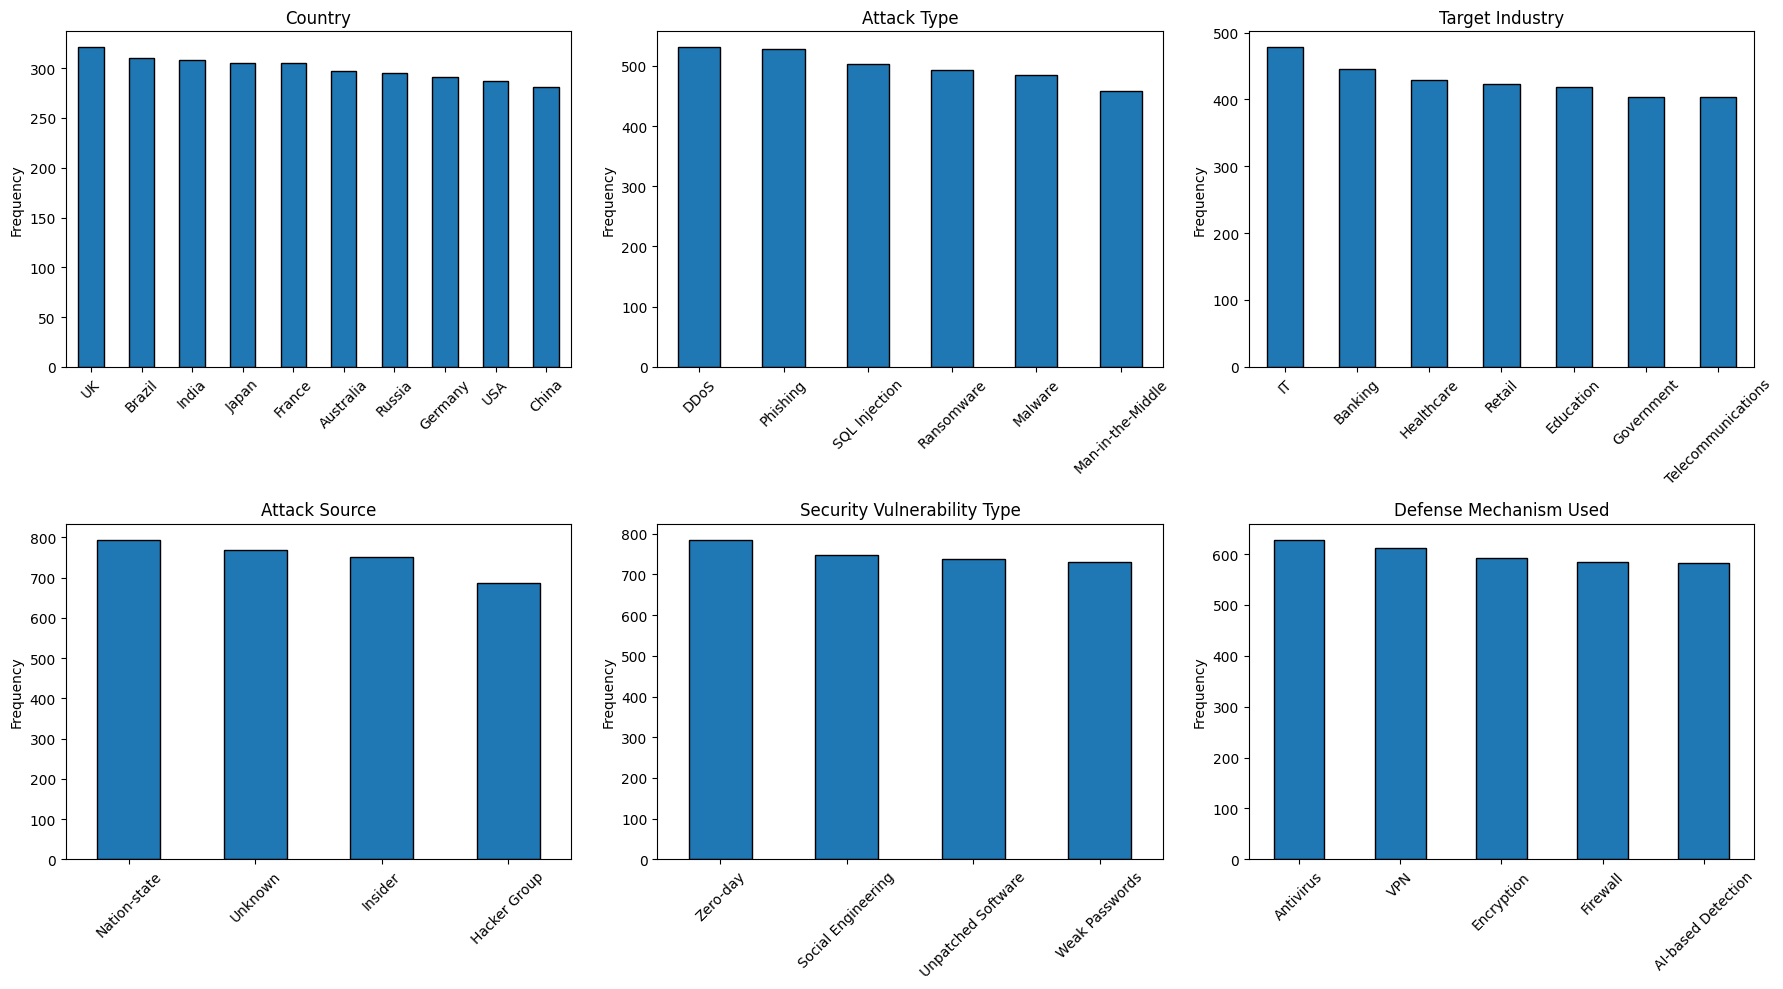

In [43]:
categorical_cols = [
    "country",
    "attack_type",
    "target_industry",
    "attack_source",
    "security_vulnerability_type",
    "defense_mechanism_used"
]

#old code before introducing plot_categorical_bars helper function
"""
plt.figure(figsize=(18, 10))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    global_cybersecuirty_threats[col].value_counts().plot(kind="bar", edgecolor="black")
    plt.title(col.replace("_", " ").title())
    plt.xlabel("")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
"""

plot_categorical_bars(
    dataframe=global_cybersecuirty_threats,
    categorical_cols=categorical_cols,
    figsize=(18, 10),
    nrows=2,
    ncols=3
)

**Observation:**

- **Country**:

    The distribution of incidents by country looks quite balanced. The UK has the highest number of records, while China has the lowest, but the differences are not very large. This suggests that the dataset covers multiple countries in a fairly even way, which is helpful for comparing cyberattack severity across locations.

- **Attack Type**:

    Among the attack types, DDoS and Phishing appear most often, while Man-in-the-Middle has the lowest count. Still, all attack types are represented with relatively similar frequencies. This is useful because it allows a fair comparison of how different attack types relate to financial loss, user impact, and incident response time.

- **Target Industry**:

    The IT sector appears most frequently in the dataset, followed by Banking and Healthcare. Government and Telecommunications have the lowest counts, but again the differences are not too large. This means the dataset includes a good spread of industries, which is important for analyzing which sectors are more strongly affected by cyber incidents.

- **Attack Source**:

    The most common attack source is Nation-state, while Hacker Group appears least often. The four categories are still relatively balanced overall. This suggests that the dataset includes different kinds of threat actors and allows comparison of whether some sources are linked to more severe attacks than others.

- **Security Vulnerability Type**:

    The vulnerability categories are very evenly distributed. Zero-day appears slightly more often than the others, while Weak Passwords is the least frequent. Since the counts are very close, this variable looks suitable for comparing whether some vulnerability types are associated with higher severity than others.

- **Defense Mechanism Used**:

    The defense mechanisms also show a balanced distribution. Antivirus is the most common, while AI-based Detection appears least often. The differences are small, which means this variable can be used to explore whether certain defense mechanisms are linked to lower losses, fewer affected users, or shorter resolution times.

**Summary:**

    Overall, all six categorical variables are distributed quite evenly. At the same time, the balanced structure of the categories may also suggest that the dataset is curated rather than fully raw real-world data.

Let's check the distributions of all numeric features

In [44]:
def plot_histograms_grid(dataframe, bin_settings, nrows, ncols, width, height):
    plt.figure(figsize=(width, height))

    for i, (col, bins) in enumerate(bin_settings.items(), 1):
        plt.subplot(nrows, ncols, i)

        plt.hist(dataframe[col], bins=bins, edgecolor="black")

        # Optional: handle missing helper gracefully
        try:
            balance_label = classify_distribution_balance(dataframe[col], bins)
            title_suffix = f" ({balance_label})"
        except NameError:
            title_suffix = ""

        pretty_col = col.replace("_", " ").title()

        plt.title(f"{pretty_col}{title_suffix}")
        plt.xlabel(pretty_col)
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

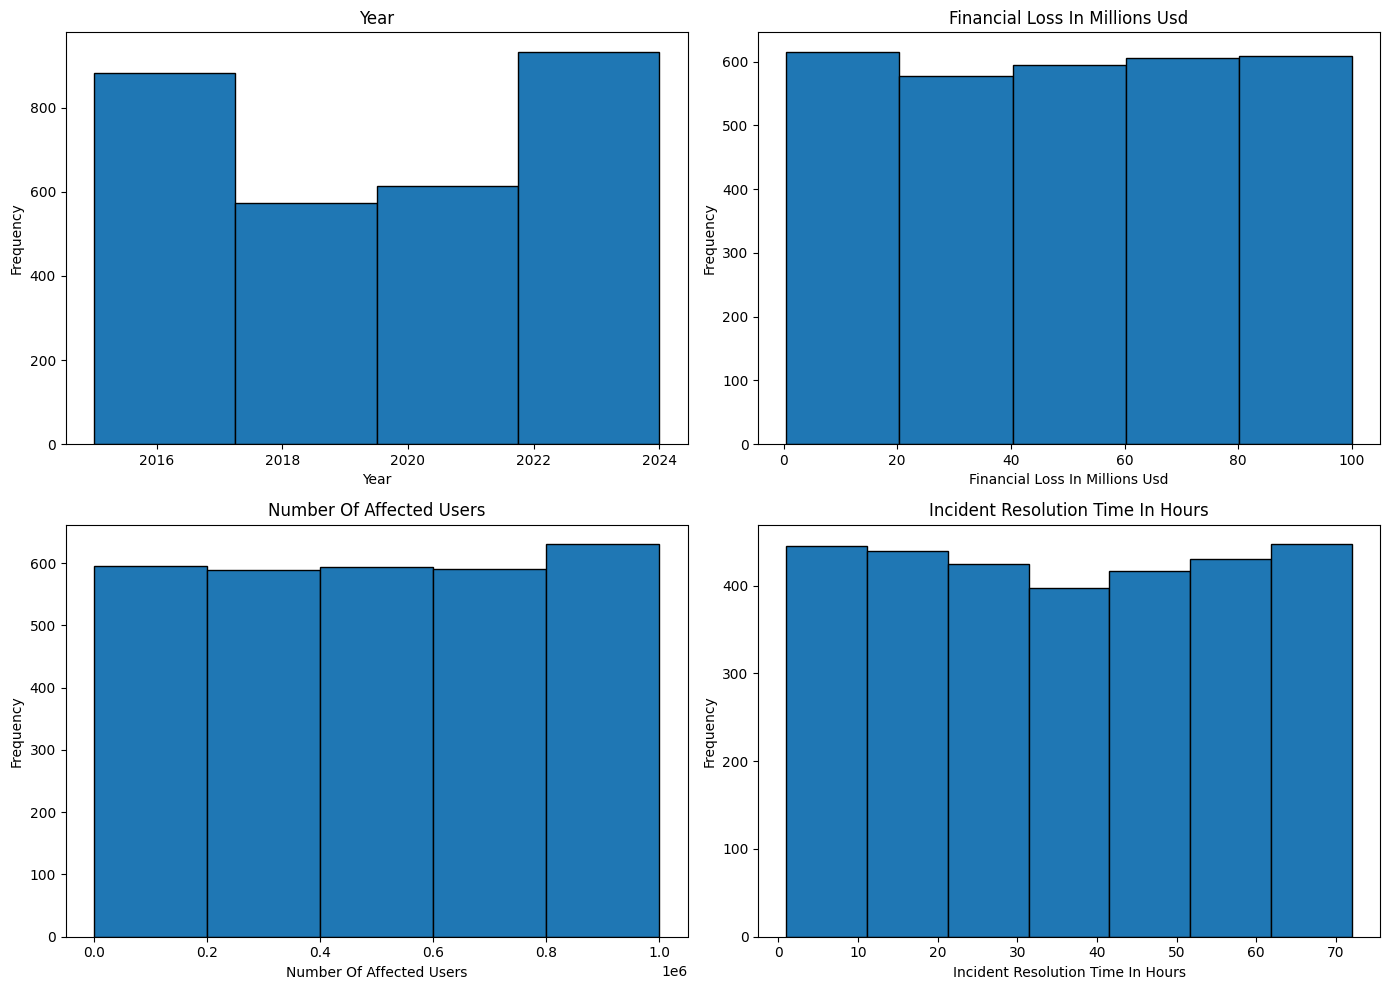

In [45]:
bin_settings = {
    "year": 4,
    "financial_loss_in_millions_usd": 5,
    "number_of_affected_users": 5,
    "incident_resolution_time_in_hours": 7
}

# old code before introducing plot_histograms_grid helper function
"""
def classify_distribution_balance(series, bins):
    counts, _ = np.histogram(series.dropna(), bins=bins)
    
    # avoid division by zero if something strange happens
    mean_count = counts.mean()
    std_count = counts.std()
    
    # coefficient of variation
    cv = std_count / mean_count if mean_count != 0 else 0
    
    if cv < 0.10:
        return "roughly even across bins"
    elif cv < 0.25:
        return "moderately uneven"
    else:
        return "strongly uneven"

plt.figure(figsize=(14, 10))

for i, (col, bins) in enumerate(bin_settings.items(), 1):
    plt.subplot(2, 2, i)
    
    plt.hist(global_cybersecuirty_threats[col], bins=bins, edgecolor="black")
    
    balance_label = classify_distribution_balance(global_cybersecuirty_threats[col], bins)
    pretty_col = col.replace("_", " ").title()
    
    plt.title(f"{pretty_col} ({balance_label})")
    plt.xlabel(pretty_col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
"""

plot_histograms_grid(
    dataframe=global_cybersecuirty_threats,
    bin_settings=bin_settings,
    nrows=2,
    ncols=2,
    width=14,
    height=10
)

**Observation:**

- **Year**:

    The distribution of `year` is modoretly uneven compared to the other numeric variables. The first and last bins have more records, while the middle bins have fewer. This means the incidents are not distributed perfectly evenly across time, but the difference is still not extreme. Overall, the dataset still covers the full period from 2015 to 2024 quite well.

- **Financial Loss in Millions USD**:

    The histogram of `financial_loss_in_millions_usd` looks quite evenly spread across the 5 bins. There is no strong concentration in only one part of the range, which means the dataset includes both lower-loss and higher-loss incidents in a balanced way.

- **Number of Affected Users**:

    The distribution of `number_of_affected_users` also looks roughly even across the bins. This suggests that the dataset contains incidents with both smaller and larger user impact, without being heavily concentrated in one range only. Because of this, the variable seems suitable for comparing how user impact changes across attack types and industries.

- **Incident Resolution Time in Hours**:

    The histogram for `incident_resolution_time_in_hours` is also quite evenly distributed, although there is a small drop in the middle range. In general, the values are spread across short, medium, and longer response times.

**Summary:**

Overall, the numeric variables show broad and fairly even distributions. Once again just like with categorical variables of `global_cybersecuirty_threats` the regular shape of the histograms again suggests that the data may be curated or synthetic, so the results should be interpreted as patterns within the dataset rather than exact real-world distributions.

#### 7.1.2. Correlations

In [46]:
def plot_correlation_matrix(dataframe, figsize_length=8, figsize_height=6, numeric_cols=None):
    """
    Plots a correlation matrix for selected numeric columns.

    Parameters:
    - dataframe (pd.DataFrame): The input dataset
    - figsize_length (int/float): Width of the plot
    - figsize_height (int/float): Height of the plot
    - numeric_cols (list): List of numeric column names to include.
                           If None, all numeric columns are used.
    """
    
    # If numeric_cols not provided, select numeric columns automatically
    if numeric_cols is None:
        numeric_cols = dataframe.select_dtypes(include=['number']).columns

    corr_matrix = dataframe[numeric_cols].corr()

    plt.figure(figsize=(figsize_length, figsize_height))
    plt.imshow(corr_matrix, cmap='Blues', interpolation="nearest")
    plt.colorbar(label="Correlation")

    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

    # Annotate values
    for i in range(len(corr_matrix.index)):
        for j in range(len(corr_matrix.columns)):
            plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", 
                     ha="center", va="center")

    plt.title("Correlation Matrix of Numeric Variables")
    plt.tight_layout()
    plt.show()

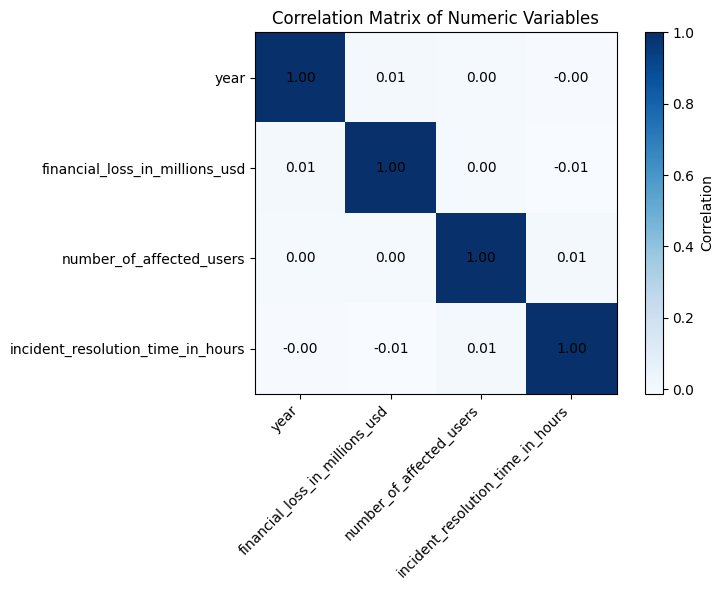

In [47]:
numeric_cols = [
    "year",
    "financial_loss_in_millions_usd",
    "number_of_affected_users",
    "incident_resolution_time_in_hours"
]

"""
corr_matrix = global_cybersecuirty_threats[numeric_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='Blues', interpolation="nearest")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Matrix of Numeric Variables")
plt.show()
"""

plot_correlation_matrix(global_cybersecuirty_threats, 8, 6, numeric_cols)

**Observation:**

The correlation matrix shows that the numeric variables in `global_cybersecuirty_threats` dataframe have no strong relationship with each other. All off-diagonal values are very close to zero, which means there is no clear association between the main numeric features.

#### 7.1.3. Financial Loss by Attack Type

<Figure size 1000x600 with 0 Axes>

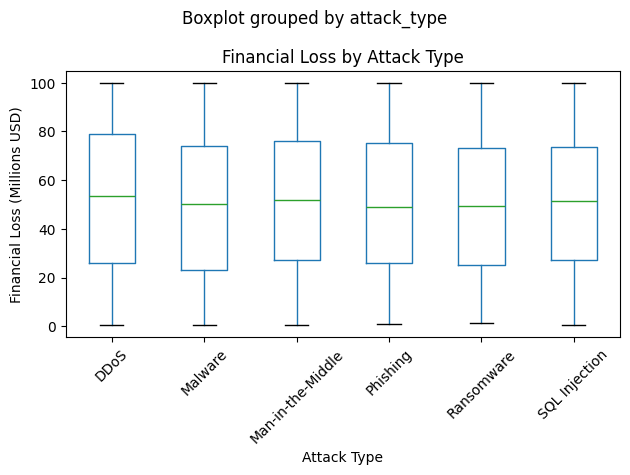

In [48]:
plt.figure(figsize=(10, 6))

global_cybersecuirty_threats.boxplot(
    column="financial_loss_in_millions_usd",
    by="attack_type",
    grid=False
)

plt.title("Financial Loss by Attack Type")
plt.xlabel("Attack Type")
plt.ylabel("Financial Loss (Millions USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**

The boxplot shows that the distributions of financial loss are very similar across all attack types. The median values are close to each other, mostly around 50 million USD, which means no attack type stands out with a clearly higher typical financial loss.

#### 7.1.4. Number of Affected Users by Target Industry

<Figure size 1200x600 with 0 Axes>

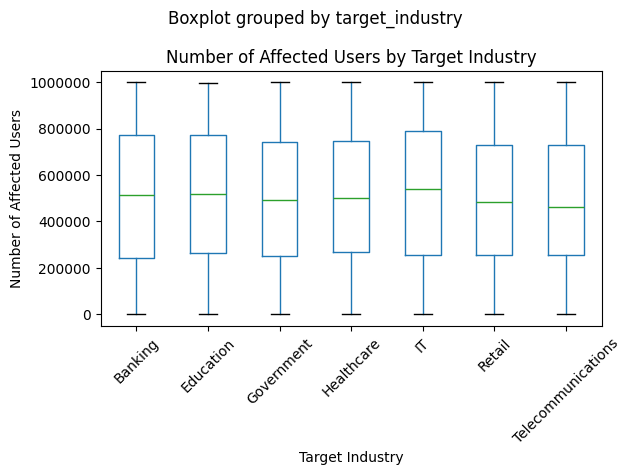

In [49]:
plt.figure(figsize=(12, 6))

global_cybersecuirty_threats.boxplot(
    column = "number_of_affected_users",
    by = "target_industry",
    grid=False
)

plt.title("Number of Affected Users by Target Industry")
plt.xlabel("Target Industry")
plt.ylabel("Number of Affected Users")
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

**Observation:**

The boxplot shows that the distributions of affected users are fairly similar across the different industries. Most medians are close to 500 000 users, which suggests that no single sector is clearly separated from the others in terms of typical user impact. This result suggests that industry alone may not be enough to explain user impact, and other factors should also be considered in the analysis.

Overall, this plot suggests that target industry does not create very strong differences in user impact in this dataset, although the IT sector appears to be slightly more affected than the others.

#### 7.1.5. Incident Resolution Time by Attack Source

<Figure size 1000x600 with 0 Axes>

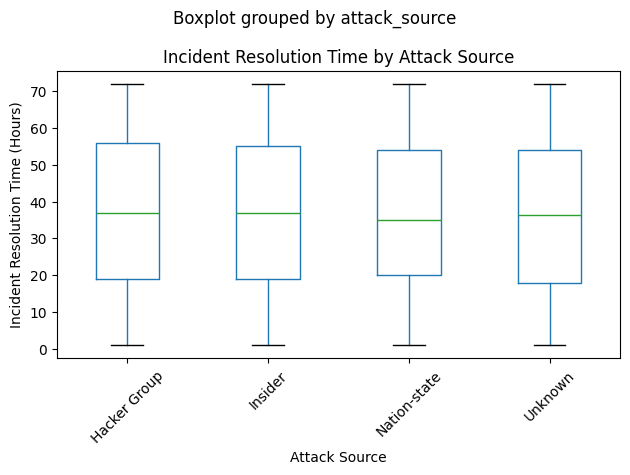

In [50]:
plt.figure(figsize=(10, 6))

global_cybersecuirty_threats.boxplot(
    column="incident_resolution_time_in_hours",
    by="attack_source",
    grid=False
)

plt.title("Incident Resolution Time by Attack Source")
plt.xlabel("Attack Source")
plt.ylabel("Incident Resolution Time (Hours)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**

The boxplot shows that the distributions of incident resolution time are fairly similar across the different attack sources. Most median values are close to **35–40 hours**, which suggests that no single attack source clearly stands out in terms of typical resolution time.

Overall, this plot suggests that attack source alone does not seem to have a strong effect on incident resolution time in this dataset.

#### 7.1.6. Financial Loss by Securit Vulnerability Types

<Figure size 1000x600 with 0 Axes>

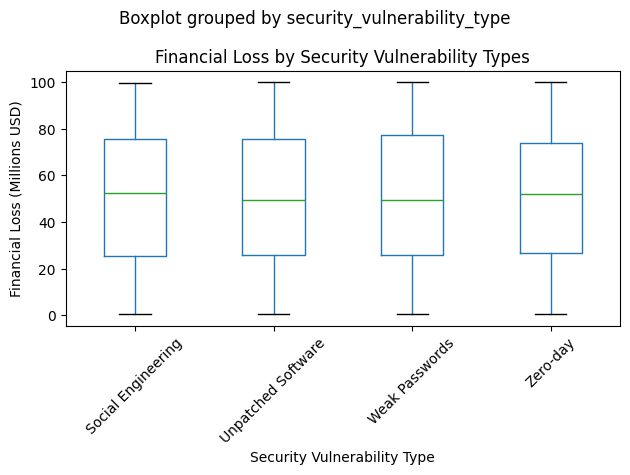

In [51]:
plt.figure(figsize=(10, 6))

global_cybersecuirty_threats.boxplot(
    column="financial_loss_in_millions_usd",
    by="security_vulnerability_type",
    grid=False
)

plt.title("Financial Loss by Security Vulnerability Types")
plt.xlabel("Security Vulnerability Type")
plt.ylabel("Financial Loss (Millions USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**

The boxplot shows that the distributions of financial loss are very similar across the four vulnerability types. The median values are all close to **50 million USD**, which suggests that no single vulnerability category is clearly associated with higher typical financial loss.

Overall, this plot suggests that security vulnerability type alone does not appear to be a strong driver of financial loss in this dataset.

#### 7.1.7. Incident Resolution Time (Hours) by Defense Mechanism Used

<Figure size 1000x600 with 0 Axes>

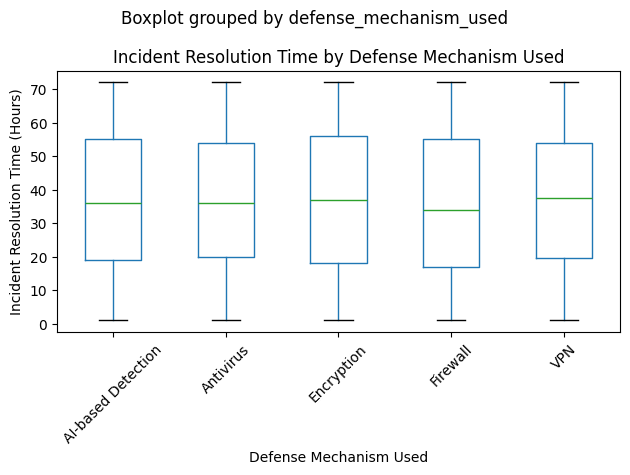

In [52]:
plt.figure(figsize=(10, 6))

global_cybersecuirty_threats.boxplot(
    column="incident_resolution_time_in_hours",
    by="defense_mechanism_used",
    grid=False
)

plt.title("Incident Resolution Time by Defense Mechanism Used")
plt.xlabel("Defense Mechanism Used")
plt.ylabel("Incident Resolution Time (Hours)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**

The boxplot shows that the distributions of incident resolution time are quite similar across the different defense mechanisms. The median values are all close to around **35–38 hours**, which suggests that no single defense mechanism clearly stands out with much faster or slower typical resolution time.

Overall, this plot suggests that defense mechanism used alone does not appear to be a strong factor in incident resolution time in this dataset.

#### 7.1.8. Which Attack Types Have the Highest Average Financial Loss? (Sub-question 1)

In [53]:
def summarize_by_group(dataframe, group_col, value_col, sort_by="mean", ascending=False):
    return (
        dataframe
        .groupby(group_col, observed=False)[value_col]
        .agg(["mean", "median", "min", "max", "count"])
        .sort_values(by=sort_by, ascending=ascending)
    )

In [54]:
financial_loss_by_attack_type = summarize_by_group(
    global_cybersecuirty_threats,
    group_col="attack_type",
    value_col="financial_loss_in_millions_usd"
)

financial_loss_by_attack_type

,mean,median,min,max,count
attack_type,,,,,
DDoS,52.035631,53.46,0.50,99.99,531
Man-in-the-Middle,51.309085,52.04,0.54,99.71,459
Phishing,50.459905,49.08,0.92,99.98,529
SQL Injection,50.013042,51.26,0.72,99.99,503
Ransomware,49.653793,49.56,1.42,99.90,493
Malware,49.418454,50.02,0.54,99.72,485


**Observation:**

The table shows that **DDoS** is associated with the **highest average financial loss**, with a mean value of about **52.04 million USD**. It is followed closely by **Man-in-the-Middle** with about **51.31 million USD**.

Overall, the table answers the first research sub-question ***"Which attack types are associated with the highest average financial loss?"*** by showing that **DDoS** is associated with the highest average financial loss, but the difference compared to the other attack types is small. This suggests that attack type alone is not a strong standalone factor for explaining financial loss in this dataset.

#### 7.1.9. Which industries or sectors experience the greatest user impact from cyber incidents? (Sub-question 2)

In [55]:
number_of_affected_users_by_target_industry = summarize_by_group(
    global_cybersecuirty_threats,
    group_col="target_industry",
    value_col="number_of_affected_users"
)

number_of_affected_users_by_target_industry

,mean,median,min,max,count
target_industry,,,,,
IT,523210.939331,541493.0,2653,999542,478
Education,513137.785203,519698.0,424,996762,419
Banking,505839.114607,513005.0,1326,998937,445
Healthcare,504130.340326,500521.0,2233,999545,429
Government,499352.431762,492909.0,1579,999635,403
Telecommunications,495203.746898,463525.0,586,999508,403
Retail,488833.063830,482700.0,984,998728,423


**Observation:**

The grouped summary table shows that the **IT** sector is associated with the highest average number of affected users, with a mean value of about 523211 users. It is followed by **Education** with about 513138 users, and **Banking** with about 505839 users while **Retail** has the lowest average number of affected users, with a mean of about 488833 users. However, the differences between industries are still not very large. All mean values are within a relatively small range, from about **488833** to **523211** users.

Overall, the table answers the second research sub-question ***"Which industries or sectors experience the greatest user impact from cyber incidents?"*** by showing that the IT sector experiences the greatest average user impact, but the difference compared to the other industries is fairly small.

In [56]:
global_cybersecuirty_threats.dtypes

country                              category
year                                    int64
attack_type                          category
target_industry                      category
financial_loss_in_millions_usd        float64
number_of_affected_users                int64
attack_source                        category
security_vulnerability_type          category
defense_mechanism_used               category
incident_resolution_time_in_hours       int64
dtype: object

#### 7.1.10. Which factors are associated with longer incident resolution times? (Sub-question 3)

In [57]:
incident_resolution_time_by_attack_sources = summarize_by_group(
    global_cybersecuirty_threats,
    group_col="attack_source",
    value_col="incident_resolution_time_in_hours"
)

incident_resolution_time_by_attack_sources

,mean,median,min,max,count
attack_source,,,,,
Hacker Group,37.212828,37.0,1,72,686
Insider,36.351064,37.0,1,72,752
Nation-state,36.329975,35.0,1,72,794
Unknown,36.091146,36.5,1,72,768


**Observation:**

The grouped summary table shows that **Hacker Group** attacks are associated with the highest average incident resolution time, with a mean of about **37.21 hours**. The median values support the same conclusion. **Hacker Group** and **Insider** both have a median of **37 hours**, while Nation-state is slightly lower at **35 hours**. However, these differences are small, and all groups remain in a very narrow range. The minimum and maximum values are exactly the same for all attack sources, from **1 hour** to **72 hours**, which also suggests that the overall distributions are very similar. This matches the earlier boxplot, where the boxes and whiskers overlapped heavily and no attack source clearly stood out. 

Overall, the table suggests that attack source is not strongly associated with longer incident resolution time in this dataset. Although Hacker Group has the highest average, the difference compared to the other categories is very small.

In [58]:
incident_resolution_time_by_attack_type = summarize_by_group(
    global_cybersecuirty_threats,
    group_col="attack_type",
    value_col="incident_resolution_time_in_hours"
)

incident_resolution_time_by_attack_type

,mean,median,min,max,count
attack_type,,,,,
Malware,37.074227,36.0,1,72,485
SQL Injection,36.906561,37.0,1,72,503
Man-in-the-Middle,36.871460,36.0,1,72,459
Ransomware,36.533469,38.0,1,72,493
Phishing,35.913043,35.0,1,72,529
DDoS,35.687382,35.0,1,72,531


**Observation:**

The grouped summary table shows that **Malware** is associated with the highest average incident resolution time, with a mean of about **37.07 hours**. The median values are also quite close. **Ransomware** and **SQL Injection** have the highest median at **38** and **37 hours**, while **Phishing** and **DDoS** are lower at **35 hours**. This suggests there are some small differences between attack types, but not large ones. The minimum and maximum values are the same for all categories, from **1** to **72 hours**, and the mean values are all within a narrow range of around **35.7** to **37.1 hours**. This means the differences between attack types are quite small.

Overall, this table suggests that attack type is not strongly associated with longer incident resolution time in this dataset. Although **Malware** has the highest average, the gap compared to the other attack types is very small.

In [59]:
incident_resolution_time_by_defence_mechanism_used = summarize_by_group(
    global_cybersecuirty_threats, 
    group_col="defense_mechanism_used",
    value_col="incident_resolution_time_in_hours"
)

incident_resolution_time_by_defence_mechanism_used

,mean,median,min,max,count
defense_mechanism_used,,,,,
VPN,36.864379,37.5,1,72,612
AI-based Detection,36.612350,36.0,1,72,583
Encryption,36.589527,37.0,1,72,592
Antivirus,36.573248,36.0,1,72,628
Firewall,35.714530,34.0,1,72,585


**Observation:**

The grouped summary table shows that **VPN** is associated with the highest average incident resolution time, with a mean of about **36.86 hours**. The median values show a similar pattern. **VPN** has the highest median at **37.5 hours**, while **Firewall** has the lowest median at **34 hours**. This suggests that incidents involving VPN tend to take slightly longer to resolve, while those involving Firewall are resolved a bit faster on average. However, the differences are still small. All mean values are within a narrow range of about **35.7** to **36.9 hours**, and the minimum and maximum values are the same for all categories, from **1** to **72 hours**. This supports the earlier boxplot, where the distributions overlapped heavily.

Overall, this table suggests that defense mechanism used is not strongly associated with longer incident resolution times in this dataset.

In [60]:
incident_resolution_time_by_security_vulnerability_type = summarize_by_group(
    global_cybersecuirty_threats,
    group_col="security_vulnerability_type",
    value_col="incident_resolution_time_in_hours"
)

incident_resolution_time_by_security_vulnerability_type

,mean,median,min,max,count
security_vulnerability_type,,,,,
Unpatched Software,37.882114,39.0,1,72,738
Social Engineering,36.459170,36.0,1,72,747
Zero-day,35.963057,37.0,1,72,785
Weak Passwords,35.623288,34.0,1,72,730


**Observation:**

The grouped summary table shows that **Unpatched Software** is associated with the highest average incident resolution time, with a mean of about **37.88 hours**. It also has the highest median value at **39 hours**, which makes it stand out more clearly than the other vulnerability categories.

Overall, this table suggests that security vulnerability type has some relationship with incident resolution time, but the effect is still moderate rather than strong. In this dataset, incidents related to **Unpatched Software** tend to take the longest to resolve on average.

**Conclusuin:**

Based on the grouped summary tables and boxplots, no single categorical variable shows a very strong effect on incident resolution time.

#### 7.1.11. Exploratory data analysis of Global Cybersecurity Threats (2015-2024): Conclusion

The EDA of **Global Cybersecurity Threats (2015-2024)** dataset suggests that the main categorical variables are associated with only small differences in financial loss, affected users, and incident resolution time. Some categories show slightly higher averages, but overall the distributions overlap strongly, which means no single factor appears to be a strong standalone driver of severity in this dataset.

### 7.2. Exploratory data analysis: Cyber Security Attacks

In [61]:
cybersecurity_attacks.dtypes

timestamp                 datetime64[ns]
source_port                        int64
destination_port                   int64
protocol                        category
packet_length                      int64
packet_type                     category
traffic_type                    category
anomaly_scores                   float64
attack_type                     category
attack_signature                category
action_taken                    category
severity_level                  category
network_segment                 category
proxy_information         string[python]
log_source                      category
malware_indicator_flag              bool
alert_triggered_flag                bool
firewall_log_flag                   bool
ids_ips_alert_flag                  bool
city                      string[python]
state                           category
dtype: object

#### 7.2.1. Distributions

Let's check the distributions of categorical features.

There are 10 categorical variables in `cybersecurity_attacks`. Nine of them have a small number of categories and can be shown together in a 3x3 layout.
The `state` column is plotted separately because it contains many more categories and would reduce the readability of the main figure.

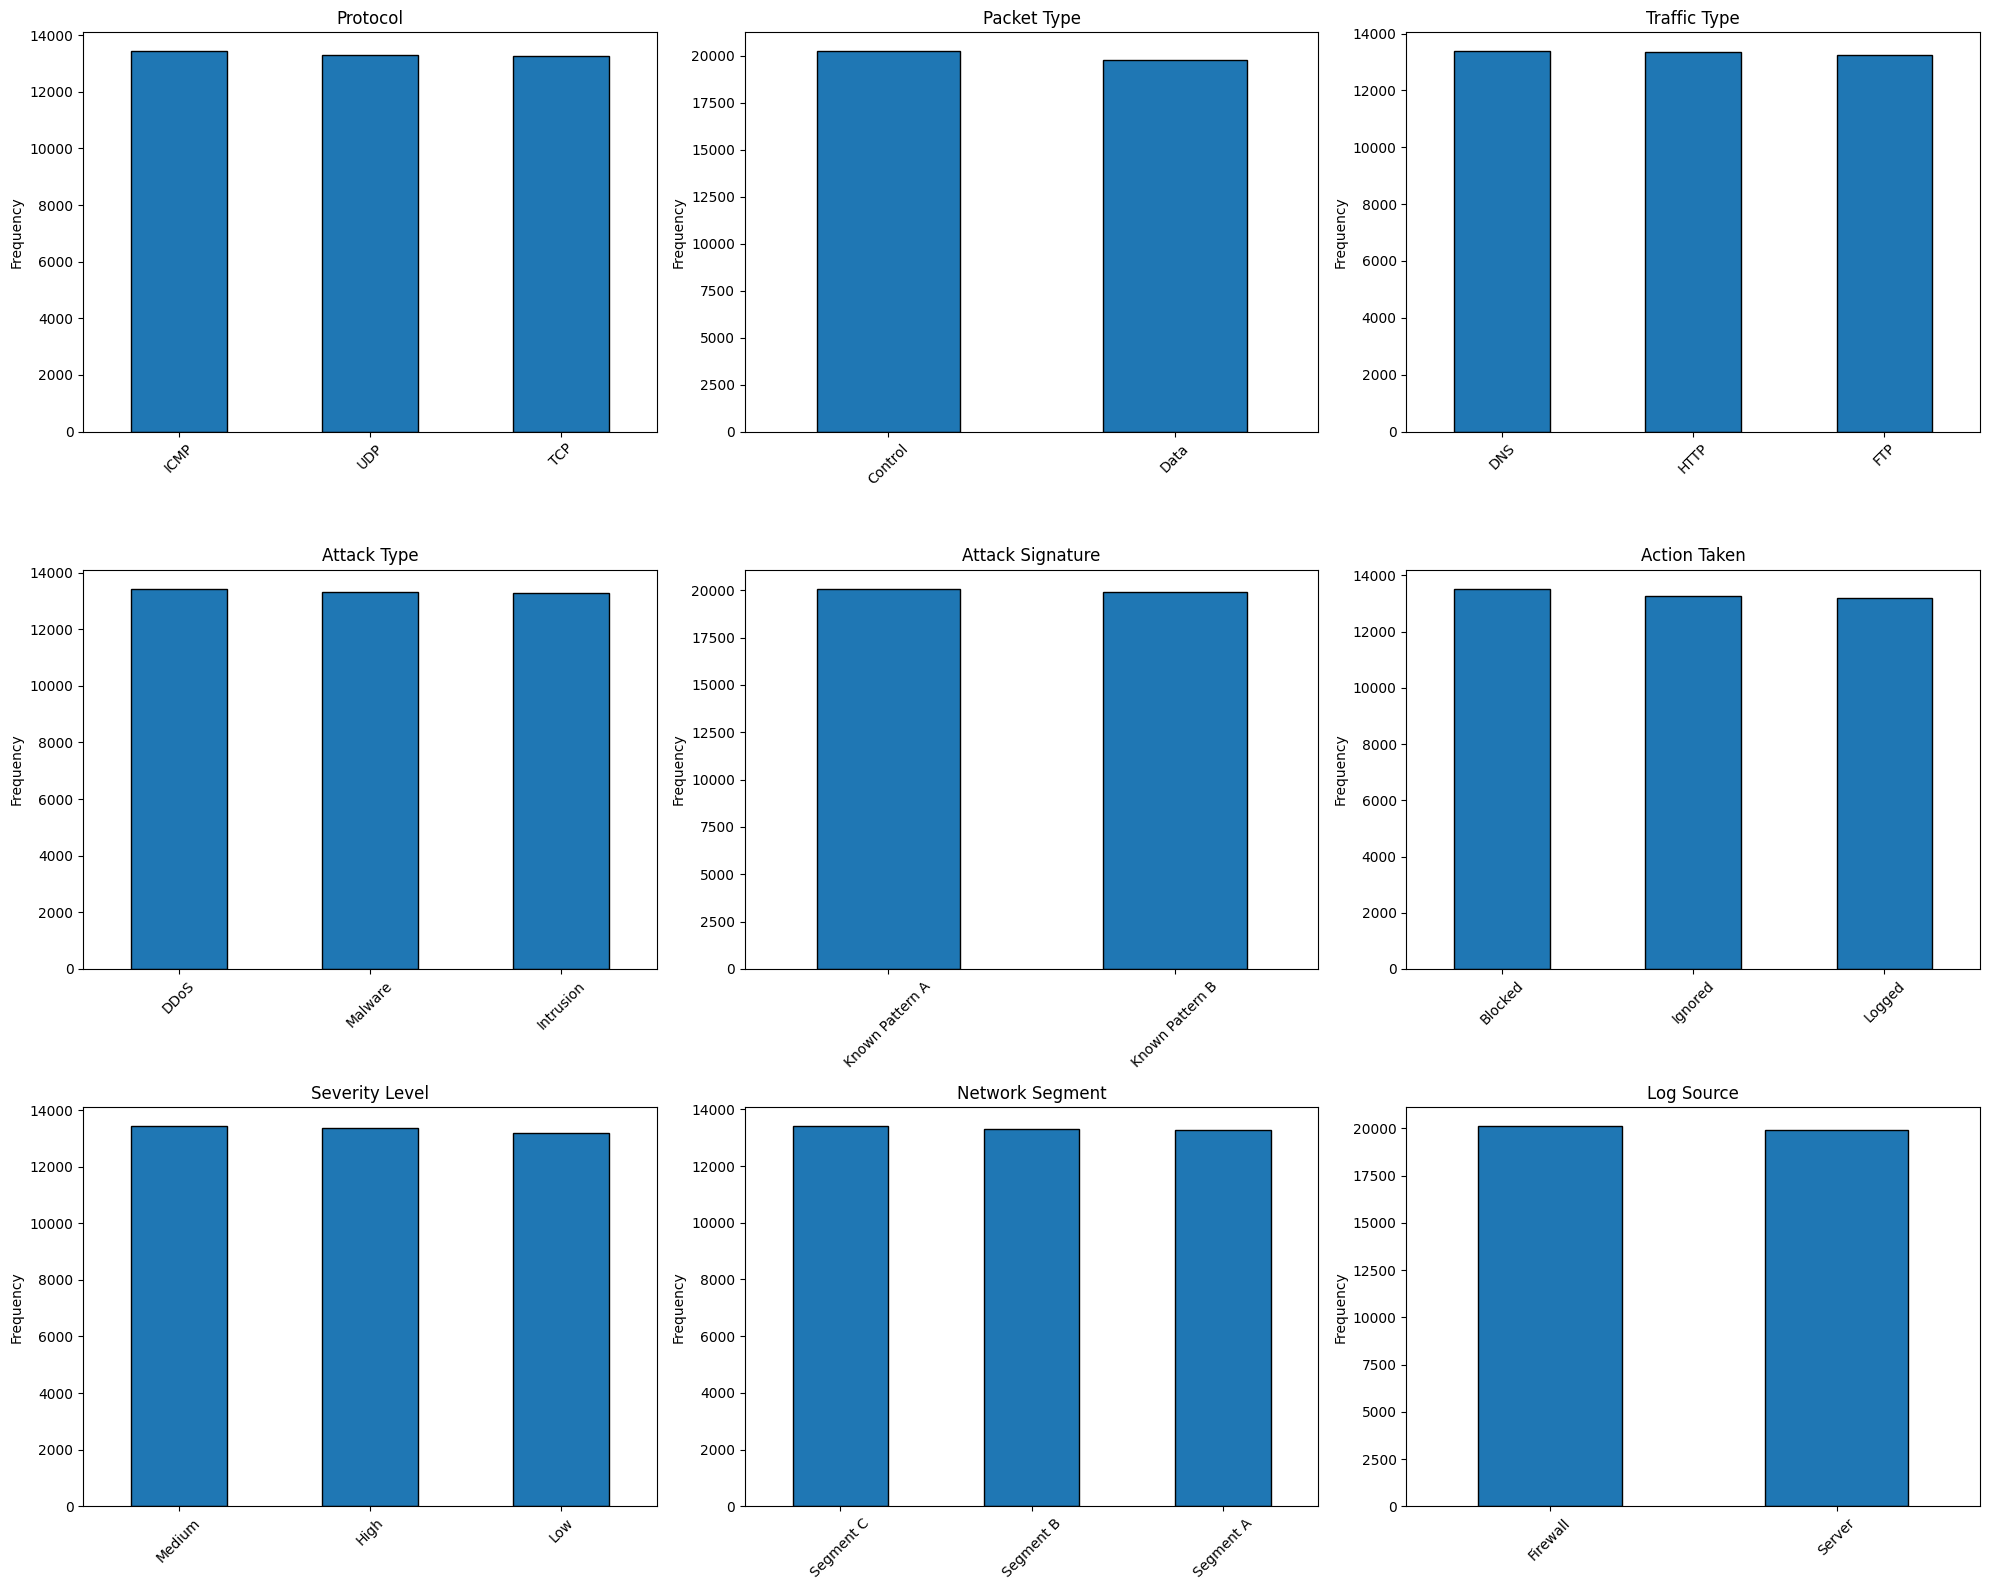

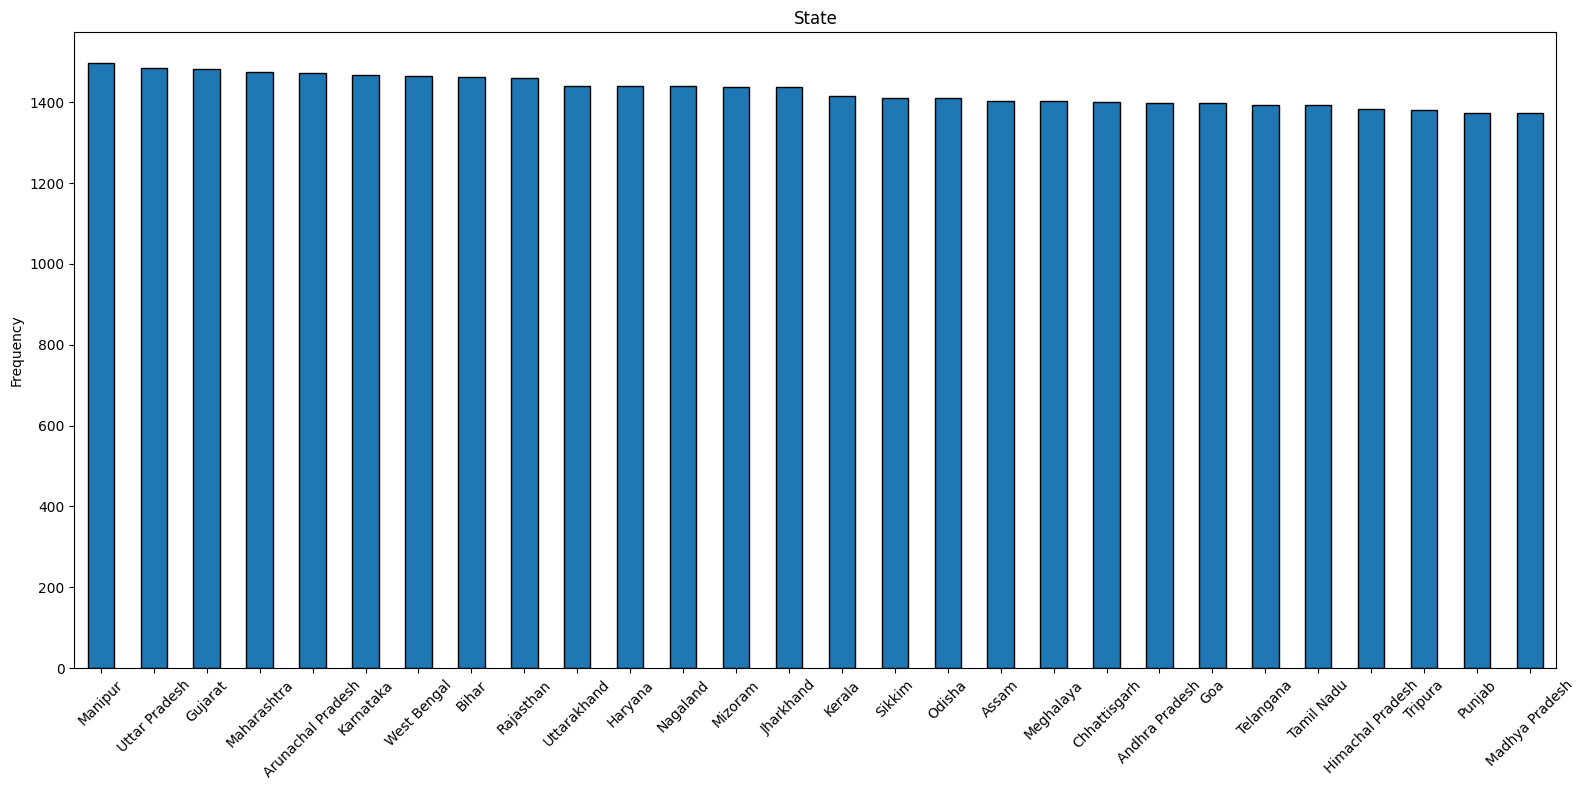

In [62]:
categorical_cols = [
    "protocol",
    "packet_type",
    "traffic_type",
    "attack_type",
    "attack_signature",
    "action_taken",
    "severity_level",
    "network_segment",
    "log_source",
]

plot_categorical_bars(
    dataframe=cybersecurity_attacks,
    categorical_cols=categorical_cols,
    figsize=(20, 16),
    nrows=3,
    ncols=3
)

plot_categorical_bars(
    dataframe=cybersecurity_attacks,
    categorical_cols=["state"],
    figsize=(16, 8),
    nrows=1,
    ncols=1
)

**Observation:**

The bar charts show that the categorical variables in `cybersecurity_attacks` dataframe are distributed very evenly overall. This can be seen for `protocol`, `packet_type`, `traffic_type`, `attack_type`, `attack_signature`, `action_taken`, `severity_level`, `network_segment`, `log_source`, and `state`, where the category counts are all very close to each other.

Overall, the very regular distributions once again suggest that the dataset may be curated rather than fully raw real-world cybersecurity data.

Let's check the distributions of all numeric features

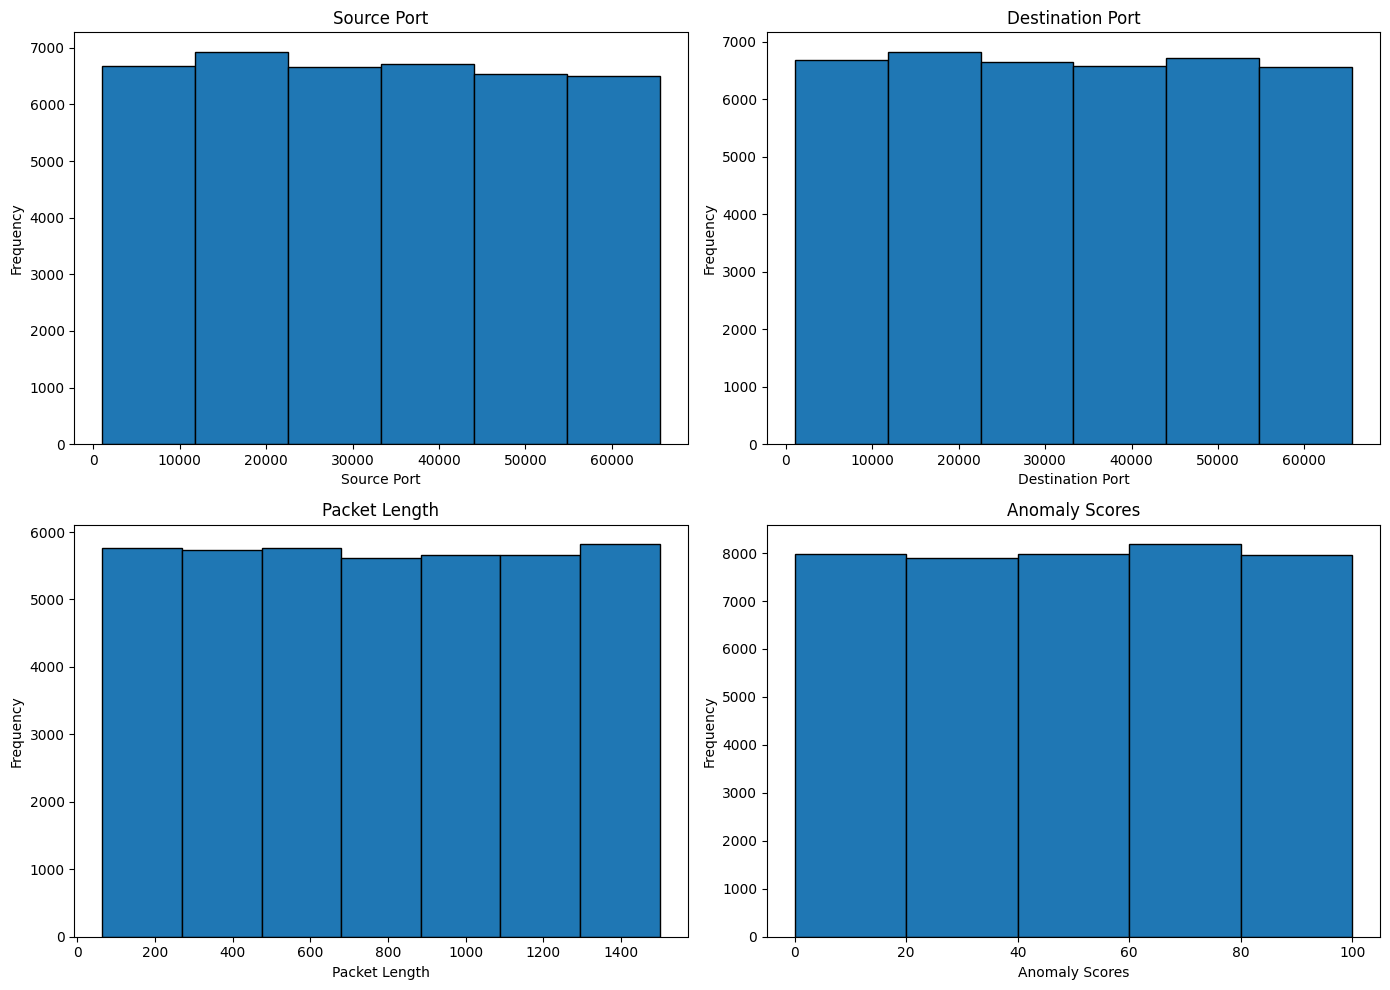

In [63]:
bin_settings = {
    "source_port": 6,
    "destination_port": 6,
    "packet_length": 7,
    "anomaly_scores": 5
}

plot_histograms_grid(
    dataframe=cybersecurity_attacks,
    bin_settings=bin_settings,
    nrows=2,
    ncols=2,
    width=14,
    height=10
)

**Observation:**

The histograms show that the four numeric variables in `cybersecurity_attacks` - `source_port`, `destination_port`, `packet_length`, and `anomaly_scores` - are all distributed quite evenly across their value ranges. None of them shows a strong concentration in only one interval, and the bar heights are fairly similar across the bins.

Once again the very regular shape of the histograms suggests that the dataset may be curated rather than fully raw real-world operational data.

#### 7.2.2. Correlations

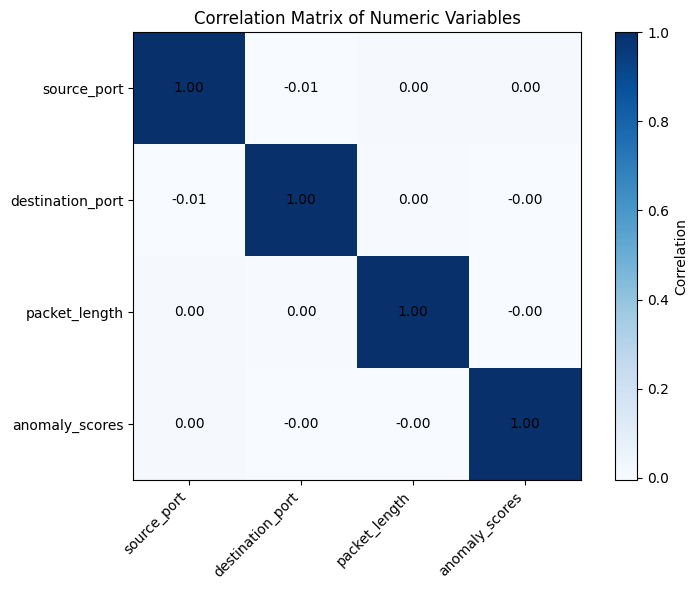

In [64]:
numeric_cols = [
    "source_port",
    "destination_port", 
    "packet_length",
    "anomaly_scores"
]

plot_correlation_matrix(cybersecurity_attacks, 8, 6, numeric_cols)

**Observation**:

The correlation matrix shows that the numeric variables in `cybersecurity_attacks` dataframe have no strong relationship with each other. All off-diagonal values are very close to zero, which means there is no clear association between the main numeric features.

#### 7.2.3. Anomaly Scores by Attack Type

In [65]:
def prettify_label(label):
    """Convert snake_case to Title Case."""
    return label.replace("_", " ").title()

def plot_boxplot_by_category(
    dataframe,
    numeric_col,
    categorical_col,
    figsize_length=10,
    figsize_height=6
):
    """
    Plots a boxplot showing the relationship between a numeric column
    and a categorical column with clean labels.
    """

    # Validation
    if numeric_col not in dataframe.columns:
        raise ValueError(f"Column '{numeric_col}' not found in dataframe.")
    if categorical_col not in dataframe.columns:
        raise ValueError(f"Column '{categorical_col}' not found in dataframe.")

    plt.figure(figsize=(figsize_length, figsize_height))

    dataframe.boxplot(
        column=numeric_col,
        by=categorical_col,
        grid=False
    )

    # Prettified labels
    pretty_num = prettify_label(numeric_col)
    pretty_cat = prettify_label(categorical_col)

    plt.title(f"{pretty_num} by {pretty_cat}")
    plt.suptitle("")  # remove pandas default title
    plt.xlabel(pretty_cat)
    plt.ylabel(pretty_num)
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

<Figure size 1000x600 with 0 Axes>

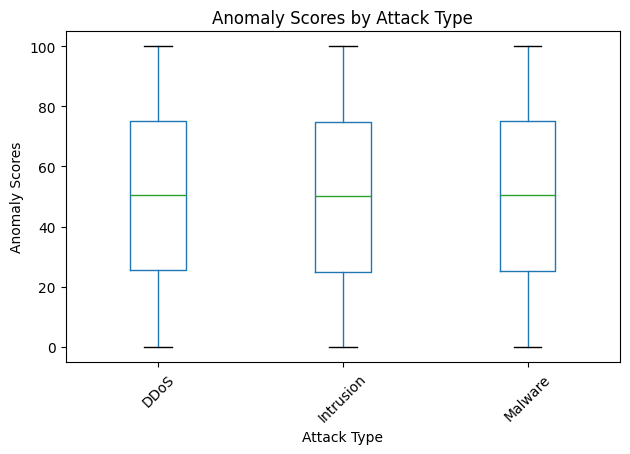

In [66]:
plot_boxplot_by_category(
    cybersecurity_attacks,
    numeric_col="anomaly_scores",
    categorical_col="attack_type"
)

**Observation:**

The boxplot shows that the distributions of anomaly scores are very similar across the three attack types. The median values are all close to 50, which suggests that no single attack type is clearly associated with higher anomaly socres..

Overall, this plot suggests that attack type alone does not appear to be a strong driver of anomaly scores in this dataset. This means that the technical severity signal measured by `anomaly_scores` is distributed quite similarly across the attack types.

#### 7.2.4. Mean and Median Anomaly Scores by Attack Type

In [67]:
anomaly_scores_by_attack_type = summarize_by_group(
    cybersecurity_attacks,
    group_col="attack_type",
    value_col="anomaly_scores"
)

anomaly_scores_by_attack_type

,mean,median,min,max,count
attack_type,,,,,
DDoS,50.235063,50.42,0.00,99.99,13428
Malware,50.125794,50.42,0.01,99.99,13307
Intrusion,49.978029,50.18,0.00,100.00,13265


**Observation:**

The grouped summary table shows that **DDoS** is associated with the highest average anomaly score, with a mean of about **50.24**. It is followed very closely by **Malware** at about **50.13**, while **Intrusion** has the lowest average at about **49.98**.

The median values tell the same story. **DDoS** and **Malware** both have a median of about **50.42**, while **Intrusion** is only slightly lower at **50.18**. The minimum and maximum values are also almost identical across all three attack types, and the counts are very similar as well.

Overall, the differences between the attack types are extremely small. This confirms the earlier boxplot, which showed strong overlap and very similar distributions. In this dataset, attack type does not appear to have a strong relationship with anomaly scores.

#### 7.2.5. Anomaly Scores by Action Taken

<Figure size 1000x600 with 0 Axes>

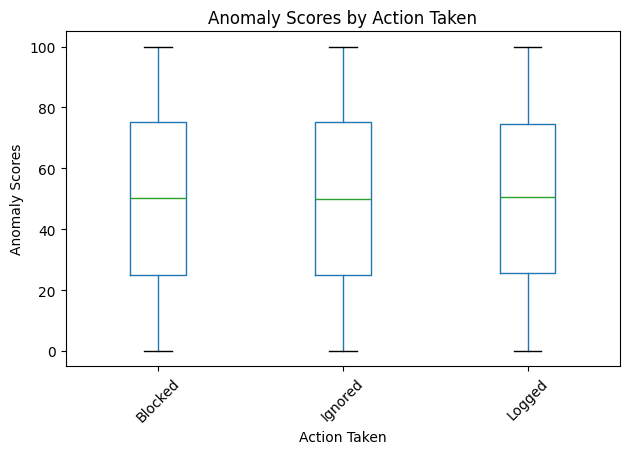

In [68]:
plot_boxplot_by_category(
    cybersecurity_attacks,
    numeric_col="anomaly_scores",
    categorical_col="action_taken"
)

**Observation:**

The boxplot shows that the distributions of anomaly scores are very similar across the three action categories: **Blocked**, **Ignored**, and **Logged**. The median values are all close to 50, which suggests that no single action is clearly associated with higher anomaly scores. The spread of the data is also almost the same in all three groups.

Overall, this plot suggests that **action taken does not appear to be a strong driver of anomaly scores** in this dataset. In other words, the technical severity signal measured by `anomaly_scores` is distributed quite similarly across the different response actions.

#### 7.2.6. Mean and Median Anomaly Scores by Action Taken

In [69]:
anomaly_scores_by_action_taken = summarize_by_group(
    cybersecurity_attacks,
    group_col="action_taken",
    value_col="anomaly_scores"
)

anomaly_scores_by_action_taken

,mean,median,min,max,count
action_taken,,,,,
Logged,50.266346,50.72,0.00,99.99,13195
Blocked,50.144817,50.25,0.00,100.00,13529
Ignored,49.929592,50.02,0.01,99.98,13276


**Observation**

The grouped summary table shows that **Logged** is associated with the highest **average anomaly score**, with a mean of about **50.27**. It is followed very closely by **Blocked** at about **50.14**, while **Ignored** has the lowest average at about **49.93**.

The median values show the same pattern. **Logged** has the highest median anomaly score at about **50.72**, followed by **Blocked** at **50.25**, and **Ignored** at **50.02**. However, the differences between the three actions are extremely small.

The minimum and maximum values are also almost identical across all groups, and the counts are very similar. This confirms the earlier boxplot, where the distributions overlapped heavily and no action category clearly stood out.

Overall, the table suggests that **action taken does not have a strong relationship with anomaly scores** in this dataset.

#### 7.2.7. Severity Level by Attack Type

Let's use **Heatmap** plot to easily see how `Low`, `Medium`, and `High` severity are distributed across the attack types.

In [70]:
severity_by_attack_type = pd.crosstab(
    cybersecurity_attacks["attack_type"],
    cybersecurity_attacks["severity_level"]
)

severity_by_attack_type

severity_level,High,Low,Medium
attack_type,,,
DDoS,4523,4450,4455
Intrusion,4427,4374,4464
Malware,4432,4359,4516


In [71]:
def plot_crosstab_heatmap(
    crosstab_table,
    title="Heatmap",
    xlabel=None,
    ylabel=None,
    figsize=(8, 5),
    cmap="Blues",
    colorbar_label="Count",
    annotate=True
):
    """
    Plot a heatmap from a pandas crosstab table using matplotlib.

    Parameters:
    - crosstab_table (pd.DataFrame): Crosstab result to visualize
    - title (str): Plot title
    - xlabel (str or None): Label for x-axis
    - ylabel (str or None): Label for y-axis
    - figsize (tuple): Figure size
    - cmap (str): Matplotlib colormap
    - colorbar_label (str): Label for the colorbar
    - annotate (bool): Whether to show values inside cells
    """
    plt.figure(figsize=figsize)
    plt.imshow(crosstab_table, cmap=cmap, aspect="auto")
    plt.colorbar(label=colorbar_label)

    x_labels = [prettify_label(str(col)) for col in crosstab_table.columns]
    y_labels = [prettify_label(str(idx)) for idx in crosstab_table.index]

    plt.xticks(range(len(x_labels)), x_labels)
    plt.yticks(range(len(y_labels)), y_labels)

    if annotate:
        for i in range(len(crosstab_table.index)):
            for j in range(len(crosstab_table.columns)):
                plt.text(
                    j,
                    i,
                    crosstab_table.iloc[i, j],
                    ha="center",
                    va="center"
                )

    plt.title(title)
    plt.xlabel(prettify_label(xlabel) if xlabel else prettify_label(crosstab_table.columns.name or ""))
    plt.ylabel(prettify_label(ylabel) if ylabel else prettify_label(crosstab_table.index.name or ""))
    plt.tight_layout()
    plt.show()

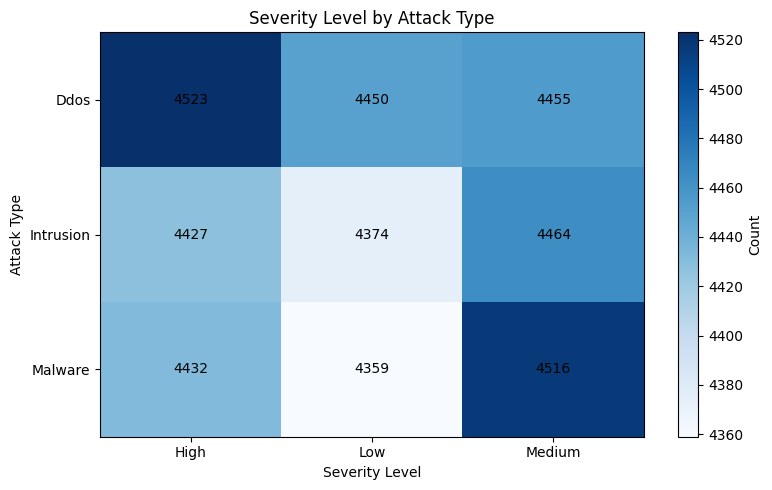

In [72]:
plot_crosstab_heatmap(
    severity_by_attack_type,
    title="Severity Level by Attack Type"
)

**Observation:**

The heatmap shows that `severity_level` is distributed quite evenly across the three attack types. The counts in all cells are close to each other, which means that **DDoS**, **Intrusion**, and **Malware** all appear with similar numbers of `High`, `Medium`, and `Low` severity events.

There are only small differences between the categories. DDoS has the highest count in the `High` severity level, while **Malware** has the highest count in the `Medium` severity level. Intrusion has slightly fewer `Low` severity cases than the other two attack types. However, these differences are small and do not suggest a strong relationship between `attack_type` and `severity_level`.

Overall, this heatmap suggests that **attack type is not strongly associated with severity level** in this dataset. The severity categories remain fairly balanced across all three attack types.

This result is consistent with the earlier analysis of `anomaly_scores` by `attack_type`, where the differences between attack types were also very small.

#### 7.2.8. Severity Level by Action Taken.

In [73]:
severity_by_action_taken = pd.crosstab(
    cybersecurity_attacks["action_taken"],
    cybersecurity_attacks["severity_level"]
)

severity_by_action_taken

severity_level,High,Low,Medium
action_taken,,,
Blocked,4530,4481,4518
Ignored,4460,4409,4407
Logged,4392,4293,4510


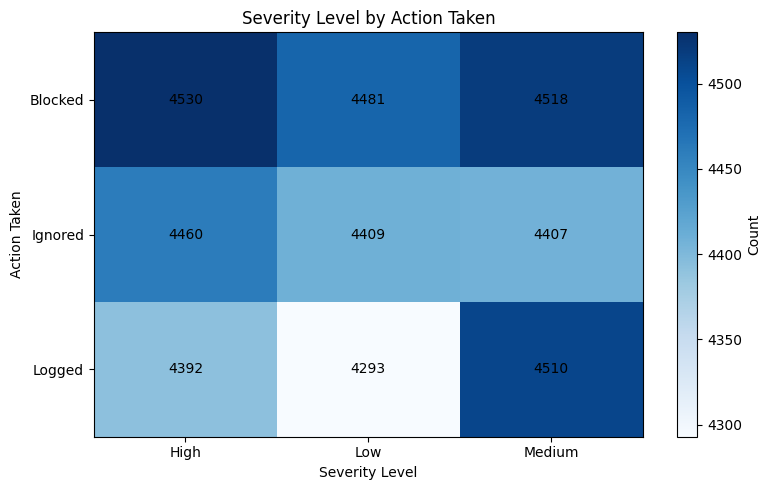

In [74]:
plot_crosstab_heatmap(
    severity_by_action_taken,
    title="Severity Level by Action Taken"
)

**Observation:**

The heatmap shows that `severity_level` is distributed quite evenly across the three action categories: `Blocked`, `Ignored`, and `Logged`. The counts in all cells are fairly close, which means none of the actions is linked to a very different severity pattern.

There are still some small differences. `Blocked` has the highest counts for both `High` and `Medium` severity events, while `Logged` has the lowest count for `Low` severity but a relatively high count for `Medium` severity. `Ignored` looks the most even across the three severity levels. However, these differences are not large enough to suggest a strong relationship between `action_taken` and `severity_level`.

Overall, this heatmap suggests that **action taken is not strongly associated with severity level** in this dataset. The severity categories remain fairly balanced across all three actions.

This result is consistent with the earlier analysis of `anomaly_scores` by `action_taken`, where the differences were also very small.

#### 7.2.9. Exploratory Data Analysis of Cyber Security Attacks: Conclusion

The exploratory analysis of the **Cyber Security Attacks** dataset shows that most variables are distributed quite evenly. This is true for both the categorical features, such as `protocol`, `traffic_type`, `attack_type`, `action_taken`, `severity_level`, and `log_source`, and the numeric features, such as `source_port`, `destination_port`, `packet_length`, and `anomaly_scores`. The correlation matrix also showed that the numeric variables do not have strong relationships with each other.

The next part of the analysis focused on operational indicators and their relation to severity. The boxplots and grouped summary tables showed that `anomaly_scores` are very similar across different `attack_type` and `action_taken` categories. The heatmaps for `severity_level` by `attack_type` and `action_taken` also showed only small differences, with the counts remaining fairly balanced across the groups.

Overall, the results suggest that the operational indicators examined in this dataset do not show strong separation between lower and higher severity cases when considered one by one. Some categories have slightly higher averages or counts, but the differences are small. This means that, in this dataset, no single operational factor appears to be a strong standalone driver of severity.

### 7.3. How do vulnerability categories, defense mechanisms, and operational indicators relate to severity? (Sub-question 4)

The exploratory analysis shows that vulnerability categories, defense mechanisms, and operational indicators have only small relationships with severity in the two datasets.

In **Global Cybersecurity Threats (2015-2024)** dataset, the differences between vulnerability types and defense mechanisms are generally small. The clearest pattern is that incidents related to Unpatched Software tend to have the longest incident resolution time. The other categories show only minor differences in financial loss and response time.

In **Cyber Security Attacks** dataset, the operational indicators also show very balanced patterns. The analyses of `anomaly_scores` and `severity_level` by `attack_type` and `action_taken` suggest that these variables do not create strong differences in severity.

Overall, the results suggest that these factors are related to severity only in a limited way when examined one by one. Among them, security vulnerability type shows the clearest pattern, but even there the differences are not very large.

## 8. Statistical Analysis, Hypothesis Testing, and Predictive Modeling

### 8.1. Statistical Methodology

- **Exploratory data analysis** helps to find patterns, but visual differences alone are not enough to support a final conclusion. Statistical tests are needed to check whether the observed differences are likely to be meaningful or could happen by chance.

- For numeric severity variables compared across several categories, the analysis uses one-way **ANOVA**. This test was chosen because it is a standard method for comparing group means and it is appropriate for this project when studying whether average severity differs between categories such as attack type, industry, or vulnerability type.

- For relationships between two categorical variables, the analysis uses the **Chi-square test of independence**. This test helps check whether variables such as severity level and action taken are related or mostly independent.

- The results of the statistical tests are interpreted together with the exploratory plots and grouped summary tables. This is important because statistical significance alone does not always mean that the practical difference is large.

- For predictive modeling, the project uses regression metrics such as **MAE**, **RMSE**, and **$R^2$**, and classification metrics such as accuracy and **F1-score**. These metrics help evaluate how well severity-related outcomes can be estimated from the available cyberattack features.

### 8.2. Hypothesis Testing for Global Cybersecurity Threats (2015-2024)

In this part of the project, hypothesis testing is used to check whether the differences observed during the exploratory analysis are statistically meaningful. For **Global Cybersecurity Threats (2015-2024)**, the tests focus on the three main severity-related variables: **financial loss**, **number of affected users**, and **incident resolution time**. Since these are numeric variables and they are compared across several categorical groups, **one-way ANOVA** is used.

**Hypotheses tested in Global Cybersecurity Threats (2015-2024):**
- H1: Mean financial loss differs by `attack_type`
- H2: Mean number of affected users differs by `target_industry`
- H3: Mean incident resolution time differs by `attack_source`
- H4: Mean incident resolution time differs by `defense_mechanism_used`
- H5: Mean incident resolution time differs by `security_vulnerability_type`

In [75]:
def run_anova_test(dataframe, group_col, value_col, alpha=0.05):
    groups = [
        group[value_col].dropna().values
        for _, group in dataframe.groupby(group_col, observed=False)
    ]
    
    f_stat, p_value = f_oneway(*groups)
    
    print(f"ANOVA test for '{value_col}' by '{group_col}'")
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_value:.6f}")
    
    if p_value < alpha:
        print("Result: Reject the null hypothesis.")
        print("Conclusion: At least one group mean is significantly different.\n")
    else:
        print("Result: Fail to reject the null hypothesis.")
        print("Conclusion: No statistically significant difference between group means.\n")
    
    return f_stat, p_value

#### 8.2.1. Hypothesis 1: Mean Financial Loss by Attack Type

**Hypotheses:**
- **Null hypothesis ($H_0$)**: The mean `financial_loss_in_millions_usd` is the same for all `attack_type` categories.
- **Alternative hypothesis ($H_1$)**: At least one `attack_type` category has a different mean `financial_loss_in_millions_usd`.

In [76]:
run_anova_test(
    dataframe=global_cybersecuirty_threats,
    group_col="attack_type",
    value_col="financial_loss_in_millions_usd"
)

ANOVA test for 'financial_loss_in_millions_usd' by 'attack_type'
F-statistic: 0.6252
p-value: 0.680564
Result: Fail to reject the null hypothesis.
Conclusion: No statistically significant difference between group means.



(np.float64(0.6252176956492915), np.float64(0.6805640335907177))

In [77]:
summarize_by_group(
    dataframe=global_cybersecuirty_threats,
    group_col="attack_type",
    value_col="financial_loss_in_millions_usd"
)

,mean,median,min,max,count
attack_type,,,,,
DDoS,52.035631,53.46,0.50,99.99,531
Man-in-the-Middle,51.309085,52.04,0.54,99.71,459
Phishing,50.459905,49.08,0.92,99.98,529
SQL Injection,50.013042,51.26,0.72,99.99,503
Ransomware,49.653793,49.56,1.42,99.90,493
Malware,49.418454,50.02,0.54,99.72,485


**Interpretation:**

The ANOVA result does not show a statistically significant difference in mean financial loss across attack types, since the p-value is greater than 0.05. This suggests that the differences observed in the boxplot and grouped summary table may be due to random variation rather than a strong relationship between attack type and financial loss.

#### 8.2.2. Hypothesis 2: Mean Number of Affected Users by Target Industry

**Hypotheses:**

- **Null hypothesis ($H_0$)**: The mean `number_of_affected_users` is the same across all `target_industry` categories.

- **Alternative hypothesis ($H_1$)**: At least one `target_industry` category has a different mean `number_of_affected_users`.

In [78]:
run_anova_test(
    dataframe=global_cybersecuirty_threats,
    group_col="target_industry",
    value_col="number_of_affected_users"
)

ANOVA test for 'number_of_affected_users' by 'target_industry'
F-statistic: 0.6909
p-value: 0.657041
Result: Fail to reject the null hypothesis.
Conclusion: No statistically significant difference between group means.



(np.float64(0.6908753169931673), np.float64(0.657040815366813))

In [79]:
summarize_by_group(
    dataframe=global_cybersecuirty_threats,
    group_col="target_industry",
    value_col="number_of_affected_users"
)

,mean,median,min,max,count
target_industry,,,,,
IT,523210.939331,541493.0,2653,999542,478
Education,513137.785203,519698.0,424,996762,419
Banking,505839.114607,513005.0,1326,998937,445
Healthcare,504130.340326,500521.0,2233,999545,429
Government,499352.431762,492909.0,1579,999635,403
Telecommunications,495203.746898,463525.0,586,999508,403
Retail,488833.063830,482700.0,984,998728,423


**Interpretation:**

The ANOVA result does not show a statistically significant difference in mean number of affected users across target industries, since the p-value is greater than 0.05. This suggests that the differences observed in the boxplot and grouped summary table may be due to random variation rather than a strong relationship between target industry and user impact.

#### 8.2.3. Hypothesis 3: Mean Incident Resolution Time by Attack Source

**Hypotheses:**

- **Null hypothesis ($H_0$)**: The mean `incident_resolution_time_in_hours ` is the same across all `attack_source` categories.

- **Alternative hypothesis ($H_1$)**: At least one `attack_source` category has a different mean `incident_resolution_time_in_hours`.

In [80]:
run_anova_test(
    dataframe=global_cybersecuirty_threats,
    group_col="attack_source",
    value_col="incident_resolution_time_in_hours"
)

ANOVA test for 'incident_resolution_time_in_hours' by 'attack_source'
F-statistic: 0.4053
p-value: 0.749183
Result: Fail to reject the null hypothesis.
Conclusion: No statistically significant difference between group means.



(np.float64(0.405329235004429), np.float64(0.7491829094097227))

In [81]:
summarize_by_group(
    dataframe=global_cybersecuirty_threats,
    group_col="attack_source",
    value_col="incident_resolution_time_in_hours"
)

,mean,median,min,max,count
attack_source,,,,,
Hacker Group,37.212828,37.0,1,72,686
Insider,36.351064,37.0,1,72,752
Nation-state,36.329975,35.0,1,72,794
Unknown,36.091146,36.5,1,72,768


**Interpretation:**

The ANOVA result does not show a statistically significant difference in mean incident resolution time across attack sources, since the p-value is greater than 0.05. This suggests that the differences observed in the boxplot and grouped summary table may be due to random variation rather than a strong relationship between attack source and incident resolution time.

#### 8.2.4. Hypothesis 4: Mean Incident Resolution Time by Defense Mechanism Used

**Hypotheses:**

- **Null hypothesis ($H_0$)**: The mean `incident_resolution_time_in_hours` is the same across all `defense_mechanism_used` categories.

- **Alternative hypothesis ($H_1$)**: At least one `defense_mechanism_used` category has a different mean `incident_resolution_time_in_hours`.

In [82]:
run_anova_test(
    dataframe=global_cybersecuirty_threats,
    group_col="defense_mechanism_used",
    value_col="incident_resolution_time_in_hours"
)

ANOVA test for 'incident_resolution_time_in_hours' by 'defense_mechanism_used'
F-statistic: 0.2691
p-value: 0.897974
Result: Fail to reject the null hypothesis.
Conclusion: No statistically significant difference between group means.



(np.float64(0.26909717808857775), np.float64(0.8979740173093))

In [83]:
summarize_by_group(
    dataframe=global_cybersecuirty_threats,
    group_col="defense_mechanism_used",
    value_col="incident_resolution_time_in_hours"
)

,mean,median,min,max,count
defense_mechanism_used,,,,,
VPN,36.864379,37.5,1,72,612
AI-based Detection,36.612350,36.0,1,72,583
Encryption,36.589527,37.0,1,72,592
Antivirus,36.573248,36.0,1,72,628
Firewall,35.714530,34.0,1,72,585


**Interpretation:**

The ANOVA result does not show a statistically significant difference in mean incident resolution time across the different defense mechanisms, since the p-value is greater than 0.05. This suggests that the differences observed in the boxplot and grouped summary table may be due to random variation rather than a strong relationship between defense mechanism used and incident resolution time.

#### 8.2.5. Hypothesis 5: Mean Incident Resolution Time by Security Vulnerability Type

**Hypotheses:**

- **Null hypothesis ($H_0$)**: The mean `incident_resolution_time_in_hours` is the same across all `security_vulnerability_type` categories.

- **Alternative hypothesis ($H_1$)**: At least one `security_vulnerability_type` category has a different mean `incident_resolution_time_in_hours`.

In [84]:
run_anova_test(
    dataframe=global_cybersecuirty_threats,
    group_col="security_vulnerability_type",
    value_col="incident_resolution_time_in_hours"
)

ANOVA test for 'incident_resolution_time_in_hours' by 'security_vulnerability_type'
F-statistic: 1.7317
p-value: 0.158309
Result: Fail to reject the null hypothesis.
Conclusion: No statistically significant difference between group means.



(np.float64(1.7316670831077747), np.float64(0.15830869257290495))

In [85]:
summarize_by_group(
    dataframe=global_cybersecuirty_threats,
    group_col="defense_mechanism_used",
    value_col="incident_resolution_time_in_hours"
)

,mean,median,min,max,count
defense_mechanism_used,,,,,
VPN,36.864379,37.5,1,72,612
AI-based Detection,36.612350,36.0,1,72,583
Encryption,36.589527,37.0,1,72,592
Antivirus,36.573248,36.0,1,72,628
Firewall,35.714530,34.0,1,72,585


**Interpretation:**

The ANOVA result does not show a statistically significant difference in mean incident resolution time across the different security vulnerability types, since the p-value is greater than 0.05. This suggests that the differences observed in the boxplot and grouped summary table may be due to random variation rather than a strong relationship between security vulnerability type and incident resolution time.

#### 8.2.6. Hypothesis Testing for Global Cybersecurity Threats (2015–2024): Conclusion

The hypothesis tests for **Global Cybersecurity Threats (2015–2024)** showed a consistent pattern across all five cases. In every ANOVA test, the p-value was greater than 0.05, which means there was not enough evidence to reject the null hypothesis. As a result, the analysis did not find statistically significant differences in the group means for financial loss, number of affected users, or incident resolution time across the tested categorical variables.

This result is consistent with the earlier exploratory analysis, where the boxplots and grouped summary tables showed only small differences between categories. Although some groups had slightly higher averages than others, these differences were not strong enough to be considered statistically significant in this dataset.

At the same time, failing to reject the null hypothesis does not prove that the group means are exactly equal. It only means that, based on the available data and the chosen significance level, there is not enough evidence to support the alternative hypotheses. Overall, the hypothesis testing suggests that the categorical factors examined in **Global Cybersecurity Threats (2015–2024)** are not strong standalone drivers of severity-related outcomes.

### 8.3. Predictive Modeling for Global Cybersecurity Threats (2015-2024)

In this part of the project, predictive modeling is used to test how well severity-related outcomes can be estimated from the available cyberattack features. For **Global Cybersecurity Threats (2015-2024)**, three regression targets are studied: financial loss, number of affected users, and incident resolution time. The models use country, year, attack type, target industry, attack source, security vulnerability type, and defense mechanism used as input features. To compare model performance, the analysis includes a simple baseline model, a linear regression model, and a random forest regressor.

#### 8.3.1. Modeling Setup

In [86]:
feature_cols = [
    "country",
    "year",
    "attack_type",
    "target_industry",
    "attack_source",
    "security_vulnerability_type",
    "defense_mechanism_used"
]

target_cols = [
    "financial_loss_in_millions_usd",
    "number_of_affected_users",
    "incident_resolution_time_in_hours"
]

In [87]:
def evaluate_regression_models(dataframe, feature_cols, target_col, test_size=0.2, random_state=42):
    X = dataframe[feature_cols]
    y = dataframe[target_col]

    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median"))
                ]),
                numeric_cols
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore"))
                ]),
                categorical_cols
            )
        ]
    )

    models = {
        "Dummy Regressor": DummyRegressor(strategy="mean"),
        "Linear Regression": LinearRegression(),
        "Random Forest Regressor": RandomForestRegressor(
            n_estimators=200,
            random_state=random_state,
            max_depth=None
        )
    }

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    results = []
    fitted_models = {}

    for model_name, model in models.items():
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results.append({
            "target": target_col,
            "model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        fitted_models[model_name] = pipeline

    results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
    return results_df, fitted_models

#### 8.3.2. Predicting Financial Loss

In [88]:
financial_loss_results, financial_loss_models = evaluate_regression_models(
    dataframe=global_cybersecuirty_threats,
    feature_cols=feature_cols,
    target_col="financial_loss_in_millions_usd"
)

financial_loss_results

,target,model,MAE,RMSE,R2
0,financial_loss_in_millions_usd,Dummy Regressor,24.610532,28.438511,-0.000143
1,financial_loss_in_millions_usd,Linear Regression,24.614145,28.515750,-0.005583
2,financial_loss_in_millions_usd,Random Forest Regressor,25.292968,29.493815,-0.075747


#### 8.3.3. Predicting Number of Affected Users

In [89]:
affected_users_results, affected_users_models = evaluate_regression_models(
    dataframe=global_cybersecuirty_threats,
    feature_cols=feature_cols,
    target_col="number_of_affected_users"
)

affected_users_results

,target,model,MAE,RMSE,R2
0,number_of_affected_users,Dummy Regressor,254793.037000,292626.511024,-0.000575
1,number_of_affected_users,Linear Regression,257309.167487,295302.143200,-0.018956
2,number_of_affected_users,Random Forest Regressor,260890.138953,303601.684233,-0.077037


#### 8.3.4. Predicting Incident Resolution Time

In [90]:
resolution_time_results, resolution_time_models = evaluate_regression_models(
    dataframe=global_cybersecuirty_threats,
    feature_cols=feature_cols,
    target_col="incident_resolution_time_in_hours"
)

resolution_time_results

,target,model,MAE,RMSE,R2
0,incident_resolution_time_in_hours,Dummy Regressor,17.845850,20.645384,-0.000452
1,incident_resolution_time_in_hours,Linear Regression,18.105398,20.936230,-0.028839
2,incident_resolution_time_in_hours,Random Forest Regressor,18.477528,21.447674,-0.079719


#### 8.3.5. Combined results table

In [91]:
dataset1_model_results = pd.concat([
    financial_loss_results,
    affected_users_results,
    resolution_time_results
], ignore_index=True)

dataset1_model_results

,target,model,MAE,RMSE,R2
0,financial_loss_in_millions_usd,Dummy Regressor,24.610532,28.438511,-0.000143
1,financial_loss_in_millions_usd,Linear Regression,24.614145,28.515750,-0.005583
2,financial_loss_in_millions_usd,Random Forest Regressor,25.292968,29.493815,-0.075747
3,number_of_affected_users,Dummy Regressor,254793.037000,292626.511024,-0.000575
4,number_of_affected_users,Linear Regression,257309.167487,295302.143200,-0.018956
5,number_of_affected_users,Random Forest Regressor,260890.138953,303601.684233,-0.077037
6,incident_resolution_time_in_hours,Dummy Regressor,17.845850,20.645384,-0.000452
7,incident_resolution_time_in_hours,Linear Regression,18.105398,20.936230,-0.028839
8,incident_resolution_time_in_hours,Random Forest Regressor,18.477528,21.447674,-0.079719


**Interpretation:**

The combined results table shows that the predictive models perform poorly for all three severity-related targets in **Global Cybersecurity Threats (2015–2024)**. In each case, the R² values are very close to zero or negative, which means the models explain little or none of the variation in the target variables. In fact, the negative R² values for **Linear Regression** and **Random Forest Regressor** show that these models perform worse than the simple **Dummy Regressor**, which only predicts the average value.

For **financial loss**, **number of affected users** and **incident resolution time**, the more advanced models do not improve prediction quality. This suggests that the available features - such as country, year, attack type, target industry, attack source, vulnerability type, and defense mechanism — do not contain enough strong predictive signal to estimate these severity outcomes accurately in this dataset.

Overall, the predictive modeling results suggest that severity-related outcomes in **Global Cybersecurity Threats (2015–2024)** can only be predicted to a very limited extent from the available cyberattack features. This is consistent with the earlier exploratory analysis and hypothesis testing, where the relationships between the features and the severity measures were also weak.

#### 8.3.6. Predictive Modeling for Global Cybersecurity Threats (2015–2024): Conclusion

The predictive modeling results for **Global Cybersecurity Threats (2015–2024)** show that the severity-related outcomes are very difficult to predict from the available cyberattack features. For all three targets - financial loss, number of affected users, and incident resolution time - the regression models produced **$R^2$ values close to zero or negative**, which means they explained little or none of the variation in the data.

Both **Linear Regression and Random Forest Regressor** performed no better, and in some cases worse, than the simple **Dummy Regressor**. This suggests that the features available in **Global Cybersecurity Threats (2015–2024)**, such as country, year, attack type, target industry, attack source, vulnerability type, and defense mechanism, do not provide enough strong predictive signal for accurate estimation of these severity outcomes.

Overall, the results suggest that, in **Global Cybersecurity Threats (2015–2024)**, severity-related outcomes can be predicted only to a very limited extent from the available features.

### 8.4. Hypothesis Testing for Cyber Security Attacks

In this part of the project, hypothesis testing is used to examine whether the operational indicators in **Cyber Security Attacks** have statistically meaningful relationships with severity. Since `anomaly_scores` is a numeric variable, one-way ANOVA is used to compare its mean across different categories. Since `severity_level` is categorical, the Chi-square test of independence is used to test whether it is associated with variables such as `attack_type` and `action_taken`.

**Hypotheses tested in Cyber Security Attacks hypothesis**:

- H6: Mean `anomaly_scores` differs by `attack_type`
- H7: Mean `anomaly_scores` differs by `action_taken`
- H8: `severity_level` is associated with `attack_type`
- H9: `severity_level` is associated with `action_taken`

#### 8.4.1. Hypothesis 6: Mean Anomaly Scores by Attack Type

**Hypotheses:**
  
- **Null hypothesis ($H_0$)**: The mean `anomaly_scores` is the same for all `attack_type` categories.
- **Alternative hypothesis ($H_1$)**: At least one `attack_type` category has a different mean `anomaly_scores`.

In [92]:
run_anova_test(
    dataframe=cybersecurity_attacks,
    group_col="attack_type",
    value_col="anomaly_scores"
)

ANOVA test for 'anomaly_scores' by 'attack_type'
F-statistic: 0.2666
p-value: 0.765996
Result: Fail to reject the null hypothesis.
Conclusion: No statistically significant difference between group means.



(np.float64(0.266580177919543), np.float64(0.7659959463947096))

In [93]:
summarize_by_group(
    dataframe=cybersecurity_attacks,
    group_col="attack_type",
    value_col="anomaly_scores"
)

,mean,median,min,max,count
attack_type,,,,,
DDoS,50.235063,50.42,0.00,99.99,13428
Malware,50.125794,50.42,0.01,99.99,13307
Intrusion,49.978029,50.18,0.00,100.00,13265


**Interpretation:**

The ANOVA result does not show a statistically significant difference in mean anomaly scores across the different attack types, since the p-value is greater than 0.05. This suggests that the differences observed earlier in the boxplot and grouped summary table may be due to random variation rather than a strong relationship between attack type and anomaly scores.

#### 8.4.2. Hypothesis 7: Mean Anomaly Scores by Action Taken

**Hypotheses:**
  
- **Null hypothesis ($H_0$)**: The mean `anomaly_scores` is the same for all `action_taken` categories.
- **Alternative hypothesis ($H_1$)**: At least one `action_taken` category has a different mean `anomaly_scores`.

In [94]:
run_anova_test(
    dataframe=cybersecurity_attacks,
    group_col="action_taken",
    value_col="anomaly_scores"
)

ANOVA test for 'anomaly_scores' by 'action_taken'
F-statistic: 0.4628
p-value: 0.629543
Result: Fail to reject the null hypothesis.
Conclusion: No statistically significant difference between group means.



(np.float64(0.4627662808590486), np.float64(0.629543121464166))

In [95]:
summarize_by_group(
    dataframe=cybersecurity_attacks,
    group_col="action_taken",
    value_col="anomaly_scores"
)

,mean,median,min,max,count
action_taken,,,,,
Logged,50.266346,50.72,0.00,99.99,13195
Blocked,50.144817,50.25,0.00,100.00,13529
Ignored,49.929592,50.02,0.01,99.98,13276


**Interpretation:**

The ANOVA result does not show a statistically significant difference in mean anomaly scores across the different action categories, since the p-value is greater than 0.05. This suggests that the differences observed earlier in the boxplot and grouped summary table may be due to random variation rather than a strong relationship between action taken and anomaly scores.

#### 8.4.3. Hypothesis 8: Association Between Severity Level and Attack Type

**Hypotheses:**
  
- **Null hypothesis ($H_0$)**: `severity_level` is independent of `attack_type`, which means there is no association between the two variables.
- **Alternative hypothesis ($H_1$)**: `severity_level` is associated with `attack_type`, which means the two variables are not independent.

In [96]:
severity_by_attack_type = pd.crosstab(
    cybersecurity_attacks["attack_type"],
    cybersecurity_attacks["severity_level"]
)

chi2, p_value, dof, expected = chi2_contingency(severity_by_attack_type)

print("Chi-square test for 'severity_level' by 'attack_type'")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

Chi-square test for 'severity_level' by 'attack_type'
Chi-square statistic: 1.7971
p-value: 0.773015
Degrees of freedom: 4


**Interpretation:**

The Chi-square test does not show a statistically significant association between `severity_level` and `attack_type`, since the p-value is greater than 0.05. This suggests that the small differences observed in the heatmap may be due to random variation rather than a strong relationship between attack type and severity level.

#### 8.4.4. Hypothesis 9: Association Between Severity Level and Action Taken

**Hypotheses:**
  
- **Null hypothesis ($H_0$)**: `severity_level` is independent of `action_taken`, which means there is no association between the two variables.
- **Alternative hypothesis ($H_1$)**: `severity_level` is associated with `action_taken`, which means the two variables are not independent.

In [97]:
severity_by_attack_type = pd.crosstab(
    cybersecurity_attacks["action_taken"],
    cybersecurity_attacks["severity_level"]
)

chi2, p_value, dof, expected = chi2_contingency(severity_by_attack_type)

print("Chi-square test for 'severity_level' by 'action_taken'")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

Chi-square test for 'severity_level' by 'action_taken'
Chi-square statistic: 3.4112
p-value: 0.491508
Degrees of freedom: 4


**Interpretation:**

The Chi-square test does not show a statistically significant association between `severity_level` and `action_taken`, since the p-value is greater than 0.05. This suggests that the small differences observed in the heatmap may be due to random variation rather than a strong relationship between action taken and severity level.

#### 8.4.5. Hypothesis Testing for Cyber Security Attacks: Conclusion

The hypothesis tests for **Cyber Security Attacks** show a consistent result across all tested cases. In both ANOVA tests, the p-values were greater than 0.05, so there was not enough evidence to reject the null hypothesis for mean anomaly scores across `attack_type` and `action_taken`. In the two Chi-square tests, the p-values were also greater than 0.05, which means there was not enough evidence to reject the null hypothesis of independence between `severity_level` and `attack_type`, or between `severity_level` and `action_taken`.

These results are consistent with the earlier exploratory analysis, where the boxplots, grouped summary tables, and heatmaps showed only small differences between categories. Overall, the hypothesis testing suggests that the operational factors examined in **Cyber Security Attacks** are not strong standalone drivers of anomaly scores or severity level. At the same time, failing to reject the null hypothesis does not prove that no relationship exists. It only means that, based on the available data and the chosen significance level, there is not enough evidence to support the alternative hypotheses.

### 8.5. Predictive Modeling for Cyber Security Attacks

In this part of the project, predictive modeling is used to test whether operational cyberattack features can help estimate severity in **Cyber Security Attacks**. The main target variable is `severity_level`, which is treated as a classification problem. The models use technical and operational features such as protocol, packet type, traffic type, attack type, action taken, network segment, log source, and the boolean alert flags.

#### 8.5.1. Modeling Setup

In [98]:
cybersecurity_attacks.dtypes

timestamp                 datetime64[ns]
source_port                        int64
destination_port                   int64
protocol                        category
packet_length                      int64
packet_type                     category
traffic_type                    category
anomaly_scores                   float64
attack_type                     category
attack_signature                category
action_taken                    category
severity_level                  category
network_segment                 category
proxy_information         string[python]
log_source                      category
malware_indicator_flag              bool
alert_triggered_flag                bool
firewall_log_flag                   bool
ids_ips_alert_flag                  bool
city                      string[python]
state                           category
dtype: object

In [99]:
feature_cols = [
    "source_port",
    "destination_port",
    "protocol",
    "packet_length",
    "packet_type",
    "traffic_type",
    "attack_type",
    "attack_signature",
    "action_taken",
    "network_segment",
    "log_source",
    "malware_indicator_flag",
    "alert_triggered_flag",
    "firewall_log_flag",
    "ids_ips_alert_flag",
    "state"
]

In [100]:
target_col = "severity_level"

I am not including:

- `timestamp`
- `proxy_information`
- `city`

because they are either too raw, too detailed, or less useful for a first model.

In [101]:
def evaluate_classification_models(dataframe, feature_cols, target_col, test_size=0.2, random_state=42):
    X = dataframe[feature_cols]
    y = dataframe[target_col]

    categorical_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("scaler", StandardScaler())
                ]),
                numeric_cols
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore"))
                ]),
                categorical_cols
            )
        ]
    )

    models = {
        "Dummy Classifier": DummyClassifier(strategy="most_frequent"),
        "Logistic Regression": LogisticRegression(
            max_iter=5000,
            solver="saga",
            random_state=random_state
        ),
        "Random Forest Classifier": RandomForestClassifier(
            n_estimators=200,
            random_state=random_state
        )
    }

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    results = []
    fitted_models = {}

    for model_name, model in models.items():
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="macro")

        results.append({
            "target": target_col,
            "model": model_name,
            "accuracy": accuracy,
            "macro_f1": f1
        })

        fitted_models[model_name] = {
            "pipeline": pipeline,
            "y_test": y_test,
            "y_pred": y_pred
        }

    results_dataframe = pd.DataFrame(results).sort_values(by="macro_f1", ascending=False)
    return results_dataframe, fitted_models

#### 8.5.2. Predicting Severity Level

In [102]:
severity_level_results, severity_level_models = evaluate_classification_models(
    dataframe=cybersecurity_attacks,
    feature_cols=feature_cols,
    target_col=target_col
)

severity_level_results

,target,model,accuracy,macro_f1
2,severity_level,Random Forest Classifier,0.336375,0.336086
1,severity_level,Logistic Regression,0.336625,0.333563
0,severity_level,Dummy Classifier,0.335875,0.167618


**Interpretation:**

The classification results show that the models perform only slightly better than the baseline when predicting severity_level in `cybersecurity_attacks`. The **Random Forest Classifier** gives the best result, with an accuracy of about 0.336 and a macro F1-score of about 0.336. **Logistic Regression** performs almost the same, with accuracy about 0.337 and macro F1-score about 0.334.

The **Dummy Classifier**, which always predicts the most frequent class, has a very similar accuracy of about 0.336, but its macro F1-score is much lower, around 0.168. This means the real models do learn a small amount of useful information, especially when performance is measured more fairly across all classes. However, the improvement is still very limited.

Overall, these results suggest that the available operational features contain only weak predictive signal for `severity_level`. In other words, severity level can be predicted only to a small extent from the features used in this model. This is consistent with the earlier exploratory analysis and hypothesis testing, where the relationships between operational indicators and severity were also weak.

To sum up, among the tested models, **Random Forest Classifier** performed best, but the overall predictive performance remained low.

#### 8.5.3. Predictive Modeling for Cyber Security Attacks: Conclusion

The predictive modeling results for **Cyber Security Attacks** show that `severity_level` can be predicted only to a limited extent from the available operational features. Both **Random Forest Classifier** and **Logistic Regression** performed only slightly better than the baseline model. Although the trained models achieved a higher macro F1-score than the **Dummy Classifier**, the overall improvement was small.

This suggests that the operational variables used in the model contain only weak predictive information about severity level. In other words, the features in **Cyber Security Attacks** are not strong enough to produce highly accurate severity predictions. This result is consistent with the earlier exploratory analysis and hypothesis testing, where the relationships between operational indicators and severity were also weak.

### 8.6. To What Extent Can Severity-Related Outcomes Be Estimated or Predicted from Available Cyberattack Features? (Sub-question 5)

The predictive modeling results from both datasets suggest that severity-related outcomes can be predicted only to a limited extent from the available cyberattack features.

In **Global Cybersecurity Threats (2015–2024)**, the regression models performed poorly for all three targets: financial loss, number of affected users, and incident resolution time. The $R^2$ values were close to zero or negative, which means the models explained little or none of the variation in these outcomes. This shows that the available features in **Global Cybersecurity Threats (2015–2024)** do not contain enough strong predictive signal.

In **Cyber Security Attacks**, the classification models performed slightly better, but the improvement over the baseline was still small. This means that the operational features contain some useful information about `severity_level`, but not enough for strong or accurate prediction.

Overall, the results suggest that severity-related outcomes can be estimated only weakly from the features used in this project. This is consistent with the earlier exploratory analysis and hypothesis testing, where most relationships with severity were also small.

## 9. Which Characteristics of Cyberattacks Are Most Strongly Associated with Higher Financial Loss, Greater User Impact, and Longer Incident Response Times? (Main Research Question)

The overall analysis suggests that no single cyberattack characteristic is strongly associated with higher financial loss, greater user impact, or longer incident response times in a consistent way across the datasets. In **Global Cybersecurity Threats (2015–2024)**, some categories showed slightly higher average severity outcomes than others: **DDoS** was associated with the highest average financial loss, the **IT** sector showed the greatest average user impact, and **Unpatched Software** was associated with the longest average incident resolution time. However, these differences were generally small, the distributions overlapped heavily, and the hypothesis tests did not show statistically significant differences. In **Cyber Security Attacks**, the operational indicators such as `attack_type`, `action_taken`, `anomaly_scores`, and `severity_level` also showed only weak relationships. 

Overall, the findings suggest that the available cyberattack features have only limited explanatory power, and that severity is likely influenced by a more complex combination of factors rather than by one strong standalone characteristic.

## 10. Limitations

This project has several limitations that should be considered when interpreting the results.

First, both datasets look very regular and balanced. This may mean that they are curated or partly synthetic, so the results should not be treated as a perfect picture of real-world cyber incidents.

Second, the two datasets could not be merged directly row by row, because they do not describe the same incidents and do not share a common key. Because of this, they were used as complementary sources instead of one fully combined dataset.

Another limitation is that many of the patterns found in the analysis were quite weak. The hypothesis tests did not show statistically significant differences in the tested cases, and the predictive models also performed poorly, especially for **Global Cybersecurity Threats (2015–2024)**. This suggests that the available features do not explain severity very well.

There were also some limits in the available variables. In **Cyber Security Attacks**, several columns had many missing values or were too detailed to use in their raw form, so they had to be simplified or removed. This helped make the analysis cleaner, but it may also have reduced some useful information.

Finally, this project looks at relationships between variables, but it does not prove cause and effect. Even if one category has a slightly higher average value, this does not mean it directly causes higher severity.

Overall, the results should be interpreted with some caution, but they still show how data science methods can be used to study cyberattack severity.

## 11. Conclusion

This project studied cyberattack severity using two datasets and a data science approach. The goal was to understand which cyberattack characteristics are related to higher financial loss, greater user impact, and longer incident resolution time.

In **Global Cybersecurity Threats (2015–2024)**, some categories had slightly higher average severity values. For example, **DDoS** had the highest average financial loss, the **IT sector** had the highest average number of affected users, and **Unpatched Software** was linked to the longest average incident resolution time. However, these differences were small.

In **Cyber Security Attacks**, the analysis focused on operational indicators such as `anomaly_scores`, `severity_level`, `attack_type`, and `action_taken`. Here too, the differences between groups were small and the distributions were quite balanced.

The hypothesis tests and predictive models supported the same general conclusion. In both datasets, the statistical results were weak, and the models showed limited predictive power. This means that the available features do not explain cyberattack severity very well on their own.

Overall, the project suggests that no single characteristic is a strong standalone driver of cyberattack severity. Instead, severity seems to depend on a more complex combination of factors. Even so, the project shows how data cleaning, visualization, hypothesis testing, and predictive modeling can be used together to study cybersecurity data in a structured way.

## 12. Resources

1. [Global Cybersecurity Threats (2015–2024)](https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024)

   *Used as the main dataset for analyzing financial loss, number of affected users, and incident resolution time.*
   
2. [Cyber Security Attacks](https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks/data)

   *Used as the supporting dataset for analyzing operational indicators such as anomaly scores, severity level, and action taken.*

3. **Python library:** [pandas](https://pandas.pydata.org/docs/user_guide/index.html#user-guide)

   *Used for data loading, cleaning, transformation, grouping, and summary statistics.*

4. **Python library:** [matplotlib](https://matplotlib.org/stable/tutorials/index.html)

   *Used for creating bar charts, histograms, boxplots, and heatmaps.*

5. **Python library:** [SciPy](https://docs.scipy.org/doc/scipy/reference/stats.html)

   *Used for statistical hypothesis testing, including one-way ANOVA and Chi-square tests.*

6. **Python library:** [scikit-learn](https://scikit-learn.org/stable/getting_started.html)

   *Used for predictive modeling, preprocessing, train-test splitting, and model evaluation.*

7. **Additional learning resources:**

   *These four YouTube videos were helpful for understanding the basics of NumPy, SciPy, Pandas, Data Science, and Scikit-learn, as well as the differences between them.*
   - [Data Science Explained Simply (In 17 Minutes)](https://www.youtube.com/watch?v=Z0RqSzRaa8M)
   - [NumPy vs Pandas](https://www.youtube.com/watch?v=KHoEbRH46Zk)
   - [NumPy vs SciPy](https://www.youtube.com/watch?v=l3s-_8uTBVA)
   - [Scikit-Learn Full Crash Course - Python Machine Learning](https://www.youtube.com/watch?v=SIEaLBXr0rk)